In [1]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor")
sys.path.append(str(project_path))

In [2]:
import tensorflow as tf
import torch

print("TensorFlow version:", tf.__version__)
print("TensorFlow GPUs:", tf.config.list_physical_devices("GPU"))

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("PyTorch GPU:", torch.cuda.get_device_name(0))

TensorFlow version: 2.20.0
TensorFlow GPUs: []
PyTorch version: 2.11.0+cpu
PyTorch CUDA available: False


### Imports

In [3]:
from data_exploration.utils.data_loader import DataLoader
from data_exploration.utils.data_explorer import DataExplorer
from second_term_gpa_regression.utils.data_cleaner_v1 import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TerminateOnNaN
import keras
import tensorflow as tf
from keras_tuner import Hyperband
import shutil
import time

from tensorflow.keras.optimizers import Adam, SGD, RMSprop


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110})

In [4]:
# # Load the original student dataset 
# data_file = project_path / "data/Student data.csv"
# dl = DataLoader(str(data_file))
# structure_df = dl.load_and_clean_data()
# structure_df.columns.to_list()

#  # Save the cleaned dataset structure to a new CSV file
# structure_df.to_csv(project_path / "data/structured_student_data.csv", index=False)

In [5]:
# ------ Helper Classes for Custom Metrics ------
class RMSEMetric(tf.keras.metrics.Metric):
    """Dataset-level RMSE accumulated across batches."""

    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name="sse", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        squared_errors = tf.square(y_true - y_pred)
        self.sse.assign_add(tf.reduce_sum(squared_errors))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        return tf.sqrt(tf.math.divide_no_nan(self.sse, self.count))

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

class R2Metric(tf.keras.metrics.Metric):
    """Dataset-level R-squared metric accumulated across batches."""

    def __init__(self, name="r2", **kwargs):
        super().__init__(name=name, **kwargs)
        self.ss_res = self.add_weight(name="ss_res", initializer="zeros")
        self.sum_y = self.add_weight(name="sum_y", initializer="zeros")
        self.sum_y_sq = self.add_weight(name="sum_y_sq", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sum_y.assign_add(tf.reduce_sum(y_true))
        self.sum_y_sq.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        ss_tot = self.sum_y_sq - tf.square(self.sum_y) / (self.count + tf.keras.backend.epsilon())
        return 1.0 - tf.math.divide_no_nan(self.ss_res, ss_tot + tf.keras.backend.epsilon())

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

In [61]:
# ----- Helper Functions -----
def print_header(name):
    """Print a compact section header."""
    print("\n" + f" {name} ".center(72, "=") + "\n")


def custom_callback(monitor, mode, patience, filepath):
    """Early stopping and model checkpoint callbacks for training."""
    es = EarlyStopping(monitor=monitor, patience=patience, restore_best_weights=True, verbose=1, mode=mode)
    mc = ModelCheckpoint(filepath=filepath, monitor=monitor, verbose=1, save_best_only=True, mode=mode)
    return es, mc


def get_target_scale(scaler_obj=None):
    scaler_obj = scaler_obj or globals().get('scaler', None)
    if scaler_obj is None or not hasattr(scaler_obj, 'data_min_') or not hasattr(scaler_obj, 'data_max_'):
        return 1.0
    return float(np.asarray(scaler_obj.data_max_ - scaler_obj.data_min_).ravel()[0])


def plot_regression_history(history, title_prefix='Model', scaler_obj=None):
    target_scale = get_target_scale(scaler_obj)
    mse_scale = target_scale ** 2

    train_mae = np.asarray(history.history['mae']) * target_scale
    val_mae = np.asarray(history.history['val_mae']) * target_scale
    train_loss = np.asarray(history.history['loss']) * mse_scale
    val_loss = np.asarray(history.history['val_loss']) * mse_scale

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(train_mae, label='Train MAE')
    axes[0].plot(val_mae, label='Val MAE')
    axes[0].set(title=f'{title_prefix} MAE', xlabel='Epoch', ylabel='MAE (GPA)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(train_loss, label='Train Loss')
    axes[1].plot(val_loss, label='Val Loss')
    if 'rmse' in history.history:
        axes[1].plot(np.asarray(history.history['rmse']) * target_scale, '--', label='Train RMSE')
        axes[1].plot(np.asarray(history.history['val_rmse']) * target_scale, '--', label='Val RMSE')
    axes[1].set(title=f'{title_prefix} Loss & RMSE', xlabel='Epoch', ylabel='Value (GPA / GPA²)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if 'r2' in history.history:
        axes[2].plot(history.history['r2'], label='Train R² (Scaled y)')
        axes[2].plot(history.history['val_r2'], label='Val R² (Scaled y)')
        axes[2].set(title=f'{title_prefix} R² (Scaled y)', xlabel='Epoch', ylabel='R²')
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best = int(np.argmin(history.history['val_loss']))
    get = lambda values: f"{np.asarray(values)[best]:.4f}"

    print(f"\nBest Epoch: {best + 1}")
    print('-' * 40)
    print(f"MAE (GPA)   -> Train: {get(train_mae)} | Val: {get(val_mae)}")
    if 'rmse' in history.history:
        print(f"RMSE (GPA)  -> Train: {get(np.asarray(history.history['rmse']) * target_scale)} | Val: {get(np.asarray(history.history['val_rmse']) * target_scale)}")
    print(f"Loss (GPA²) -> Train: {get(train_loss)} | Val: {get(val_loss)}")
    if 'r2' in history.history:
        print(f"R² (Scaled y) -> Train: {get(history.history['r2'])} | Val: {get(history.history['val_r2'])}")


def get_optimizer(name, learning_rate, clipnorm=None):
    optimizer_kwargs = {'learning_rate': learning_rate}
    if clipnorm is not None:
        optimizer_kwargs['clipnorm'] = clipnorm

    if name == 'adam':
        return Adam(**optimizer_kwargs)
    if name == 'sgd':
        return SGD(momentum=0.9, **optimizer_kwargs)
    if name == 'rmsprop':
        return RMSprop(**optimizer_kwargs)
    raise ValueError(f'Unsupported optimizer: {name}')


def build_dense_model(input_dim, layer_specs):
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])
    for spec in layer_specs:
        model.add(Dense(spec['units'], activation=spec['activation']))
        if spec.get('batch_norm', False):
            model.add(BatchNormalization())
        if spec.get('dropout', 0.0) > 0:
            model.add(Dropout(spec['dropout']))
    model.add(Dense(1))
    return model


def compile_regression_model(model, optimizer_name, learning_rate, clipnorm=None):
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate, clipnorm=clipnorm),
        loss='mse',
        metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
    )
    return model


def inverse_transform_target(values, scaler):
    return scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).flatten()


def evaluate_model_original_scale(model, X_split, y_split, scaler, split_name='Split', verbose=0, print_summary=True):
    y_pred_scaled = np.asarray(model.predict(X_split, verbose=verbose)).ravel()
    y_true_scaled = np.asarray(y_split).ravel()

    if not np.isfinite(y_true_scaled).all():
        bad_count = int(np.size(y_true_scaled) - np.isfinite(y_true_scaled).sum())
        raise ValueError(f"{split_name} target contains {bad_count} non-finite value(s).")
    if not np.isfinite(y_pred_scaled).all():
        bad_count = int(np.size(y_pred_scaled) - np.isfinite(y_pred_scaled).sum())
        raise ValueError(f"{split_name} prediction contains {bad_count} non-finite value(s).")

    y_true_actual = inverse_transform_target(y_split, scaler)
    y_pred_actual = inverse_transform_target(y_pred_scaled, scaler)
    r2_original = float(r2_score(y_true_actual, y_pred_actual))
    r2_scaled = float(r2_score(y_true_scaled, y_pred_scaled))

    metrics = {
        'split': split_name,
        'rmse': float(mean_squared_error(y_true_actual, y_pred_actual) ** 0.5),
        'mse': float(mean_squared_error(y_true_actual, y_pred_actual)),
        'mae': float(mean_absolute_error(y_true_actual, y_pred_actual)),
        'r2_original': r2_original,
        'r2_scaled': r2_scaled,
    }

    if print_summary:
        print(f"{split_name} RMSE: {metrics['rmse']:.4f}")
        print(f"{split_name} MSE:  {metrics['mse']:.4f}")
        print(f"{split_name} MAE:              {metrics['mae']:.4f}")
        print(f"{split_name} R² (Original GPA): {metrics['r2_original']:.4f}")
        print(f"{split_name} R² (Scaled y):     {metrics['r2_scaled']:.4f}")

    prediction_df = pd.DataFrame({
        'Actual GPA': y_true_actual,
        'Predicted GPA': y_pred_actual,
    })
    prediction_df['Residual'] = prediction_df['Actual GPA'] - prediction_df['Predicted GPA']
    prediction_df['Absolute Error'] = prediction_df['Residual'].abs()
    prediction_df['Squared Error'] = prediction_df['Residual'] ** 2
    prediction_df = prediction_df.sort_values('Absolute Error', ascending=False).reset_index(drop=True)

    return metrics, prediction_df


def empty_regression_metrics(split_name):
    return {
        'split': split_name,
        'rmse': np.nan,
        'mse': np.nan,
        'mae': np.nan,
        'r2_original': np.nan,
        'r2_scaled': np.nan,
    }


def get_best_epoch_from_history(history, monitor='val_loss'):
    values = np.asarray(history.history.get(monitor, []), dtype=float)
    if values.size == 0:
        return None

    finite_mask = np.isfinite(values)
    if not finite_mask.any():
        return None

    safe_values = np.where(finite_mask, values, np.inf)
    return int(np.argmin(safe_values)) + 1


def get_non_finite_history_event(history):
    for metric_name, values in history.history.items():
        values_arr = np.asarray(values, dtype=float)
        non_finite_idx = np.where(~np.isfinite(values_arr))[0]
        if non_finite_idx.size:
            return int(non_finite_idx[0]) + 1, metric_name
    return None, None


def format_metrics_display(df):
    return df.rename(columns={
        'rmse': 'RMSE (GPA)',
        'mse': 'MSE (GPA²)',
        'mae': 'MAE (GPA)',
        'r2_original': 'R² (Original GPA)',
        'r2_scaled': 'R² (Scaled y)',
    })


def format_local_search_display(df):
    return df.rename(columns={
        'trial': 'Trial',
        'trial_name': 'Trial Name',
        'optimizer': 'Optimizer',
        'learning_rate': 'Learning Rate',
        'batch_size': 'Batch Size',
        'best_epoch': 'Best Epoch',
        'val_rmse': 'Val RMSE (GPA)',
        'val_mae': 'Val MAE (GPA)',
        'val_r2_original': 'Val R² (Original GPA)',
        'val_r2_scaled': 'Val R² (Scaled y)',
        'test_rmse': 'Test RMSE (GPA)',
        'test_mae': 'Test MAE (GPA)',
        'test_r2_original': 'Test R² (Original GPA)',
        'test_r2_scaled': 'Test R² (Scaled y)',
        'status': 'Status',
        'failure_reason': 'Failure Reason',
        'architecture': 'Architecture',
    })


def plot_prediction_diagnostics(prediction_df, title_prefix='Model'):
    actual = prediction_df['Actual GPA']
    predicted = prediction_df['Predicted GPA']
    residuals = prediction_df['Residual']
    plot_min = min(actual.min(), predicted.min())
    plot_max = max(actual.max(), predicted.max())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(x=actual, y=predicted, color='#4c78a8', alpha=0.65, ax=axes[0])
    axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'r--', linewidth=1.5)
    axes[0].set_title(f'{title_prefix}: Actual vs Predicted')
    axes[0].set_xlabel('Actual GPA')
    axes[0].set_ylabel('Predicted GPA')
    axes[0].set_xlim(plot_min, plot_max)
    axes[0].set_ylim(plot_min, plot_max)
    axes[0].grid(True, alpha=0.3)

    sns.scatterplot(x=predicted, y=residuals, color='#f58518', alpha=0.65, ax=axes[1])
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
    axes[1].set_title(f'{title_prefix}: Residuals vs Predicted')
    axes[1].set_xlabel('Predicted GPA')
    axes[1].set_ylabel('Residual')
    axes[1].grid(True, alpha=0.3)

    sns.histplot(residuals, bins=20, kde=True, color='#54a24b', ax=axes[2])
    axes[2].axvline(0, color='red', linestyle='--', linewidth=1.2)
    axes[2].set_title(f'{title_prefix}: Residual Distribution')
    axes[2].set_xlabel('Residual')
    axes[2].set_ylabel('Count')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_and_plot_diagnostics(model, X_split, y_split, scaler, split_name='Split', title_prefix=None, verbose=0, print_summary=True, display_top_errors=False, top_n=15):
    metrics, prediction_df = evaluate_model_original_scale(
        model,
        X_split,
        y_split,
        scaler,
        split_name=split_name,
        verbose=verbose,
        print_summary=print_summary,
    )

    if display_top_errors:
        display(prediction_df.head(top_n))

    plot_prediction_diagnostics(prediction_df, title_prefix=title_prefix or split_name)
    return metrics, prediction_df


def plot_experiment_comparison(comparison_df):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.barplot(data=comparison_df, x='Model', y='r2_original', hue='Split', palette='Blues', ax=axes[0])
    axes[0].set_title('R² Comparison (Original GPA)')
    axes[0].set_ylabel('R²')
    axes[0].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='r2_scaled', hue='Split', palette='Greens', ax=axes[1])
    axes[1].set_title('R² Comparison (Scaled y)')
    axes[1].set_ylabel('R²')
    axes[1].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='rmse', hue='Split', palette='Oranges', ax=axes[2])
    axes[2].set_title('RMSE Comparison')
    axes[2].set_ylabel('RMSE (GPA)')
    axes[2].grid(True, axis='y', alpha=0.3)

    axes[1].legend_.remove()
    axes[2].legend_.remove()
    for ax in axes:
        ax.tick_params(axis='x', rotation=12)

    plt.tight_layout()
    plt.show()


def plot_local_search_summary(local_search_results_df, top_n=8):
    plot_df = local_search_results_df.copy()
    if 'status' in plot_df.columns:
        plot_df = plot_df[plot_df['status'] == 'completed'].copy()
    plot_df = plot_df.dropna(subset=['val_rmse', 'val_r2_original'])

    if plot_df.empty:
        print('No successful local search trials available to plot.')
        return

    top_df = plot_df.head(top_n).copy().sort_values('val_r2_original')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.scatterplot(
        data=plot_df,
        x='val_rmse',
        y='val_r2_original',
        hue='optimizer',
        size='best_epoch',
        sizes=(60, 220),
        palette='viridis',
        ax=axes[0],
    )
    axes[0].set_title('Local Search: Validation RMSE vs R² (Original GPA)')
    axes[0].set_xlabel('Validation RMSE (GPA)')
    axes[0].set_ylabel('Validation R² (Original GPA)')
    axes[0].grid(True, alpha=0.3)

    sns.barplot(data=top_df, x='val_r2_original', y='trial_name', hue='optimizer', dodge=False, palette='Blues', ax=axes[1])
    axes[1].set_title(f'Top {top_n} Local Search Trials')
    axes[1].set_xlabel('Validation R² (Original GPA)')
    axes[1].set_ylabel('Trial')
    axes[1].grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

def get_feature_groups(feature_columns):
    base_features = [
        'first_term_gpa',
        'high_school_average_mark',
        'math_score',
        'fast_track',
        'coop',
        'residency',
        'age_group',
        'english_grade',
        'first_language',
        'funding',
        'gender',
        'previous_education',
        'hs_math_interaction',
        'gpa_hs_interaction',
        'gpa_math_interaction',
        'gpa_english_interaction',
        'first_term_gpa_sq',
        'preparedness_gap',
        'hs_math_gap',
        'gpa_category',
        
    ]
    grouped = {}
    assigned = set()

    for feature in base_features:
        cols = [
            col for col in feature_columns
            if col == feature or (col.startswith(f'{feature}_') and not col.endswith('_missing'))
        ]
        if cols:
            grouped[feature] = cols
            assigned.update(cols)

    missing_flag_cols = [col for col in feature_columns if col.endswith('_missing')]
    for col in missing_flag_cols:
        grouped[col] = [col]
        assigned.add(col)

    for col in feature_columns:
        if col not in assigned:
            grouped[col] = [col]

    return grouped


def prepare_grouped_importance_model_input(model, X_df):
    if not isinstance(X_df, pd.DataFrame):
        raise TypeError('Grouped permutation importance expects X_df to be a pandas DataFrame with feature columns.')

    X_array = np.asarray(X_df, dtype=np.float32)
    input_shape = getattr(model, 'input_shape', None)

    if input_shape is None:
        return X_array

    if isinstance(input_shape, list):
        if len(input_shape) != 1:
            raise ValueError('Grouped permutation importance only supports single-input models.')
        input_shape = input_shape[0]

    if len(input_shape) == 2:
        expected_features = input_shape[1]
        if expected_features is not None and X_array.shape[1] != expected_features:
            raise ValueError(
                f'Model expects {expected_features} features, but grouped importance received {X_array.shape[1]}.'
            )
        return X_array

    if len(input_shape) == 3:
        expected_steps = input_shape[1]
        expected_channels = input_shape[2]
        if expected_steps is not None and X_array.shape[1] != expected_steps:
            raise ValueError(
                f'Model expects {expected_steps} timesteps, but grouped importance received {X_array.shape[1]} features.'
            )
        if expected_channels not in (None, 1):
            raise ValueError(
                f'Grouped permutation importance only supports sequence models with 1 channel, got {expected_channels}.'
            )
        return X_array.reshape(X_array.shape[0], X_array.shape[1], 1)

    raise ValueError(
        f'Unsupported model input rank {len(input_shape)} for grouped permutation importance.'
    )


def compute_grouped_permutation_importance(model, X_df, y_scaled, scaler, n_repeats=3, random_state=42, verbose=0):
    if not isinstance(X_df, pd.DataFrame):
        raise TypeError('Grouped permutation importance expects the tabular feature DataFrame (for example X_test), not the reshaped LSTM tensor.')

    feature_groups = get_feature_groups(list(X_df.columns))
    rng = np.random.default_rng(random_state)
    y_true_actual = inverse_transform_target(y_scaled, scaler)
    baseline_model_input = prepare_grouped_importance_model_input(model, X_df)
    baseline_pred_actual = inverse_transform_target(model.predict(baseline_model_input, verbose=verbose).ravel(), scaler)
    baseline_rmse = mean_squared_error(y_true_actual, baseline_pred_actual) ** 0.5
    baseline_r2 = r2_score(y_true_actual, baseline_pred_actual)

    rows = []
    for group_name, columns in feature_groups.items():
        rmse_increases = []
        r2_drops = []
        for _ in range(n_repeats):
            X_permuted = X_df.copy()
            perm_idx = rng.permutation(len(X_permuted))
            X_permuted.loc[:, columns] = X_permuted.iloc[perm_idx][columns].to_numpy()
            perm_model_input = prepare_grouped_importance_model_input(model, X_permuted)
            perm_pred_actual = inverse_transform_target(model.predict(perm_model_input, verbose=verbose).ravel(), scaler)
            perm_rmse = mean_squared_error(y_true_actual, perm_pred_actual) ** 0.5
            perm_r2 = r2_score(y_true_actual, perm_pred_actual)
            rmse_increases.append(perm_rmse - baseline_rmse)
            r2_drops.append(baseline_r2 - perm_r2)

        rows.append({
            'Feature Group': group_name,
            'RMSE Increase (Mean)': float(np.mean(rmse_increases)),
            'RMSE Increase (Std)': float(np.std(rmse_increases)),
            'R² Drop (Mean)': float(np.mean(r2_drops)),
            'Grouped Columns': ', '.join(columns),
        })

    importance_df = pd.DataFrame(rows).sort_values(['RMSE Increase (Mean)', 'R² Drop (Mean)'], ascending=False).reset_index(drop=True)
    return importance_df


def plot_grouped_feature_importance(importance_df, title='Grouped Feature Importance'):
    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=importance_df.sort_values('RMSE Increase (Mean)'),
        x='RMSE Increase (Mean)',
        y='Feature Group',
        hue='Feature Group',
        palette='crest',
        dodge=False,
        legend=False,
    )
    plt.title(title)
    plt.xlabel('Mean RMSE Increase after Group Permutation')
    plt.ylabel('Feature Group')
    plt.tight_layout()
    plt.show()

### Data Acquisition

In [7]:
#----- Main Code -----#
np.random.seed(42)

# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
clean_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

In [8]:
# Check the dataset by replacing ? with NaN and drop duplicates -- Cleaning is conducted later by the DataCleaner class
temp_df = clean_df
temp_df = temp_df.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
skim(temp_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ float64     │ 15    │                                                          │
│ │ Number of columns │ 15     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %              ┃ mean   ┃ sd     ┃ p0 ┃ p25  ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa     │  17 │ 1.183020180932498 │  2.846 │  1.175 │  0 │ 2.25 │ 3.103 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │                    │     │                 3 │        │        │    │      │       │       │      │        │  │
│ │ second_term_gpa    │ 160 │ 11.13430758524704 │   2.82 │  1.129 │  0 │ 2.26 │ 3.028 │  3.68 │  4.5 │ ▂▁▃▆▇▆ │  │
│ │                    │     │                 2 │        │        │    │      │       │       │      │        │  │
│ │ first_language     │ 111 │ 7.724425887265136 │  1.911 │ 0.9949 │  1 │    1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │ funding            │   0 │                 0 │  2.927 │  1.258 │  1 │    2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ school             │   0 │                 0 │      6 │      0 │  6 │    6 │     6 │     6 │    6 │     ▇  │  │
│ │ fast_track         │   0 │                 0 │  1.742 │ 0.4378 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ coop               │   0 │                 0 │  1.695 │ 0.4605 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ residency          │   0 │                 0 │  1.406 │ 0.4913 │  1 │    1 │     1 │     2 │    2 │ ▇    ▅ │  │
│ │ gender             │   0 │                 0 │  1.775 │ 0.4197 │  1 │    2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_education │   4 │ 0.278357689631176 │  1.275 │ 0.5678 │  0 │    1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ age_group          │   4 │ 0.278357689631176 │  2.632 │  1.421 │  1 │    2 │     3 │     3 │    8 │ ▇▇▁▁ ▁ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ high_school_averag │ 743 │ 51.70494084899095 │  77.15 │  12.07 │ 17 │   70 │  77.5 │    85 │  108 │   ▂▇▇▂ │  │
│ │ e_mark             │     │                   │        │        │    │      │       │       │      │        │  │
│ │ math_score         │ 462 │ 32.15031315240083 │  32.56 │  10.71 │  6 │   23 │    32 │    43 │   50 │ ▁▅▇▇▅▇ │  │
│ │                    │     │                 4 │        │        │    │      │       │       │      │        │  │
│ │ english_grade      │  45 │ 3.131524008350730 │   8.03 │  1.716 │  1 │    7 │     8 │     9 │   10 │   ▁ ▇▇ │  │
│ │                    │     │                 5 │        │        │    │      │       │       │      │        │  │
│ │ first_year_persist │   0 │                 0 │ 0.7919 │ 0.4061 │  0 │    1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ ence               │     │                   │      

In [9]:
# Based on the above summary target variable "second_term_gpa" has 159 null values; should be dropped for regression task. 
print(f"Number of rows before dropping nulls in target variable: {clean_df.shape[0]}")

# replace ? with nan in second_term_gpa column
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
print(f"Number of rows with nulls in target variable: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
print(f"Number of rows after dropping nulls in target variable: {clean_df.shape[0]}")

Number of rows before dropping nulls in target variable: 1437
Number of rows with nulls in target variable: 160
Number of rows after dropping nulls in target variable: 1277


In [10]:
# Feature and target separation
y = clean_df["second_term_gpa"] # Target variable
X = clean_df.drop(columns=["second_term_gpa", "first_year_persistence", "school"]) # Drop school - unique value; first_year_persistence - data leakage concerns; second_term_gpa - target variable

### Data Exploration

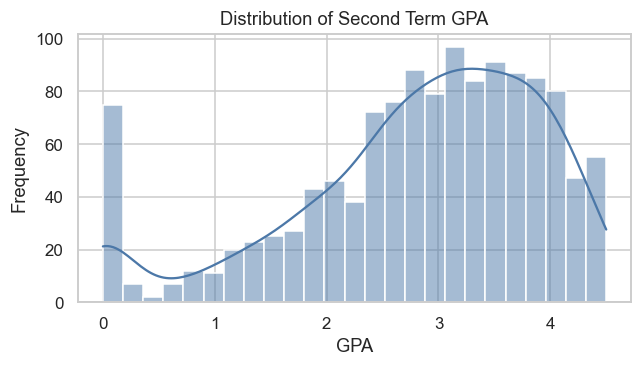

In [11]:
# explorer = DataExplorer(structured_data_file)
# explorer.run_full_analysis()

# Analyze target variable distribution
plt.figure(figsize=(6,3.5))

sns.histplot(y, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Second Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [12]:
# number of students have value 0 in second_term_gpa column
num_zero_gpa = (y == 0).sum()
print(f"Number of students with second term GPA of 0: {num_zero_gpa}")

Number of students with second term GPA of 0: 72


### Train-Test Protocol

In [13]:
# test-train split with stratification and train-only feature fitting
X_train_raw, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (893, 12), X_val: (128, 12), X_test: (256, 12)


In [14]:
# check the final training dataset
display(X_train.head())

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade
78,3.521739,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7
353,2.25,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7
1354,3.4,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8
510,4.214286,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9
338,2.547619,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9


### Data Cleaning

In [15]:
# Data cleaning
cleaner = DataCleaner(numeric_imputer="bayesian")

X_train = cleaner.fit_transform(X_train)
X_val = cleaner.transform(X_val)
X_test = cleaner.transform(X_test)

# Target standardization
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val = scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test = scaler.transform(y_test.values.reshape(-1, 1)).flatten()


In [16]:
import joblib

# save the preprocessing pipeline (DataCleaner object) to a file for later use in inference
joblib.dump(cleaner, project_path / "second_term_gpa_regression" / "models" / "best_model" / "preprocessing_pipeline.pkl")
joblib.dump(scaler, project_path / "second_term_gpa_regression" / "models" / "best_model" / "target_scaler.pkl")

# check the training after cleaning
display(X_train.head())

,first_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,high_school_average_mark_missing,english_grade_missing,...,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3,gpa_category_0,gpa_category_1,gpa_category_2,gpa_category_3
78,0.485630,1,0,0,3.0,0.335862,0.248844,7.0,1,0,...,True,False,False,True,False,False,False,False,False,True
353,-0.762264,0,0,1,2.0,0.270222,0.122663,7.0,0,0,...,False,True,False,False,True,False,False,False,True,False
1354,0.366174,1,0,0,4.0,0.253814,0.187655,8.0,1,0,...,True,False,False,False,True,False,False,False,False,True
510,1.165193,0,1,1,4.0,-0.751768,1.665857,9.0,0,0,...,False,True,False,False,True,False,False,False,False,True
338,-0.470226,0,1,1,2.0,-0.240773,-0.703704,9.0,0,0,...,False,True,False,True,False,False,False,False,True,False


### Experiment 1: Baseline Model - ANN

In [63]:
baseline_layers = [
    {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    {'units': 32, 'activation': 'relu', 'batch_norm': False, 'dropout': 0.0},
]

baseline_model = build_dense_model(X_train.shape[1], baseline_layers)
baseline_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 128)                 │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_22               │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,001 (62.50 KB)

 Trainable params: 15,617 (61.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [64]:
baseline_model = compile_regression_model(baseline_model, optimizer_name='adam', learning_rate=0.001)

baseline_es, baseline_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'regression_model.keras',
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[baseline_es, baseline_mc],
    verbose=1,
)

Epoch 1/200
24/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7359 - mae: 0.6648 - r2: -9.9172 - rmse: 0.8557 
Epoch 1: val_loss improved from None to 0.09978, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\regression_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - loss: 0.6161 - mae: 0.6004 - r2: -8.3531 - rmse: 0.7849 - val_loss: 0.0998 - val_mae: 0.2353 - val_r2: -0.7098 - val_rmse: 0.3159
Epoch 2/200
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3293 - mae: 0.4376 - r2: -4.5725 - rmse: 0.5737
Epoch 2: val_loss did not improve from 0.09978
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3030 - mae: 0.4238 - r2: -3.6002 - rmse: 0.5505 - val_loss: 0.1560 - val_mae: 0.3327 - val_r2: -1.6728 - val_rmse: 0.395

### Baseline Evaluation

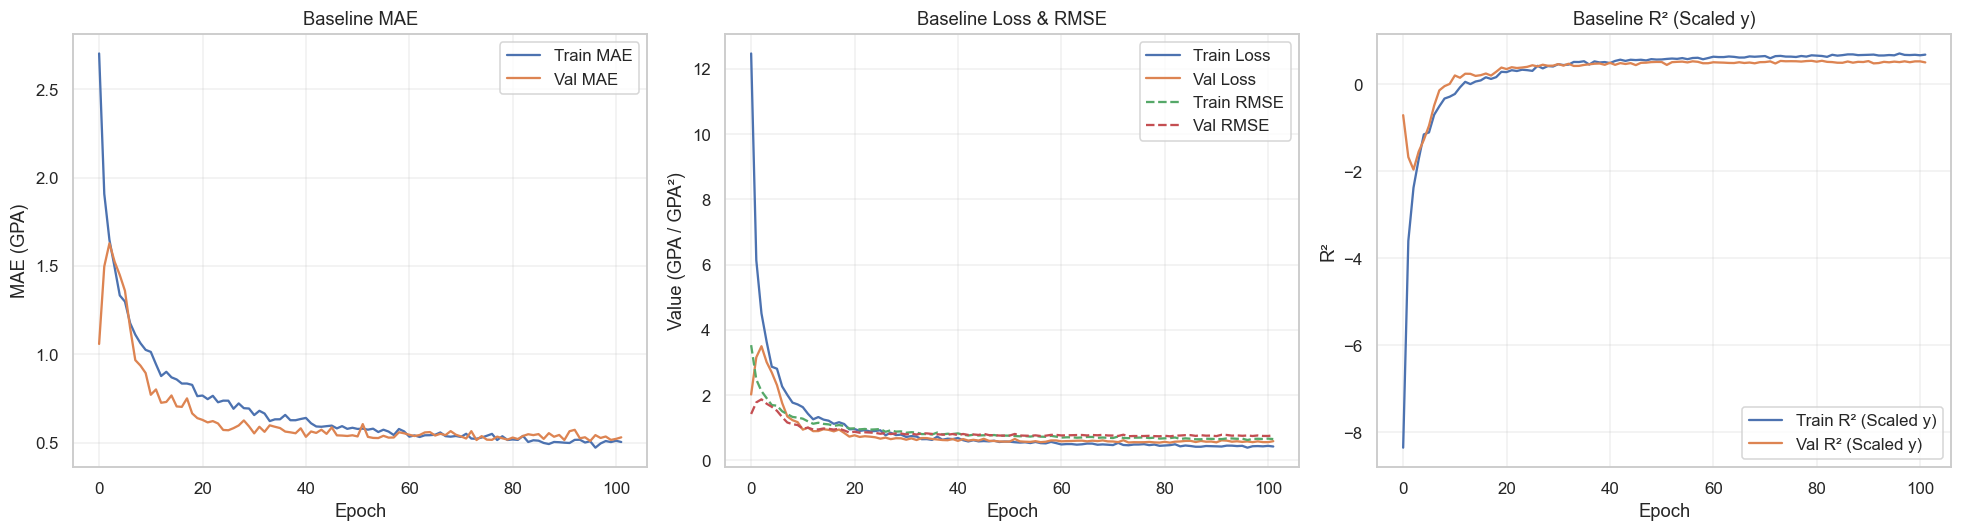


Best Epoch: 82
----------------------------------------
MAE (GPA)   -> Train: 0.5159 | Val: 0.5208
RMSE (GPA)  -> Train: 0.6820 | Val: 0.7365
Loss (GPA²) -> Train: 0.4651 | Val: 0.5424
R² (Scaled y) -> Train: 0.6513 | Val: 0.5410


In [65]:
plot_regression_history(history_baseline, title_prefix='Baseline')

In [66]:
baseline_val_metrics, baseline_val_df = evaluate_model_original_scale(
    baseline_model, X_val, y_val, scaler, split_name='Baseline Validation'
)
baseline_test_metrics, baseline_test_df = evaluate_model_original_scale(
    baseline_model, X_test, y_test, scaler, split_name='Baseline Test'
)

baseline_summary_df = pd.DataFrame([baseline_val_metrics, baseline_test_metrics]).set_index('split')
display(format_metrics_display(baseline_summary_df))
display(baseline_test_df.head(15))

Baseline Validation RMSE: 0.7365
Baseline Validation MSE:  0.5424
Baseline Validation MAE:              0.5208
Baseline Validation R² (Original GPA): 0.5410
Baseline Validation R² (Scaled y):     0.5410
Baseline Test RMSE: 0.6226
Baseline Test MSE:  0.3877
Baseline Test MAE:              0.4779
Baseline Test R² (Original GPA): 0.6486
Baseline Test R² (Scaled y):     0.6486


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline Validation,0.736493,0.542422,0.520806,0.541020,0.541020
Baseline Test,0.622622,0.387658,0.477928,0.648617,0.648617


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.000000,0.511276,2.488724,2.488724,6.193749
1,0.000000,2.206035,-2.206035,2.206035,4.866590
2,2.978261,1.076268,1.901993,1.901993,3.617579
3,1.857143,0.071256,1.785887,1.785887,3.189391
4,3.222222,1.586969,1.635253,1.635253,2.674052
5,0.000000,1.567344,-1.567344,1.567344,2.456566
6,0.000000,1.537590,-1.537590,1.537590,2.364183
7,3.375000,1.870920,1.504080,1.504080,2.262256
8,4.020833,2.570307,1.450526,1.450526,2.104026
9,0.250000,1.617203,-1.367203,1.367203,1.869245


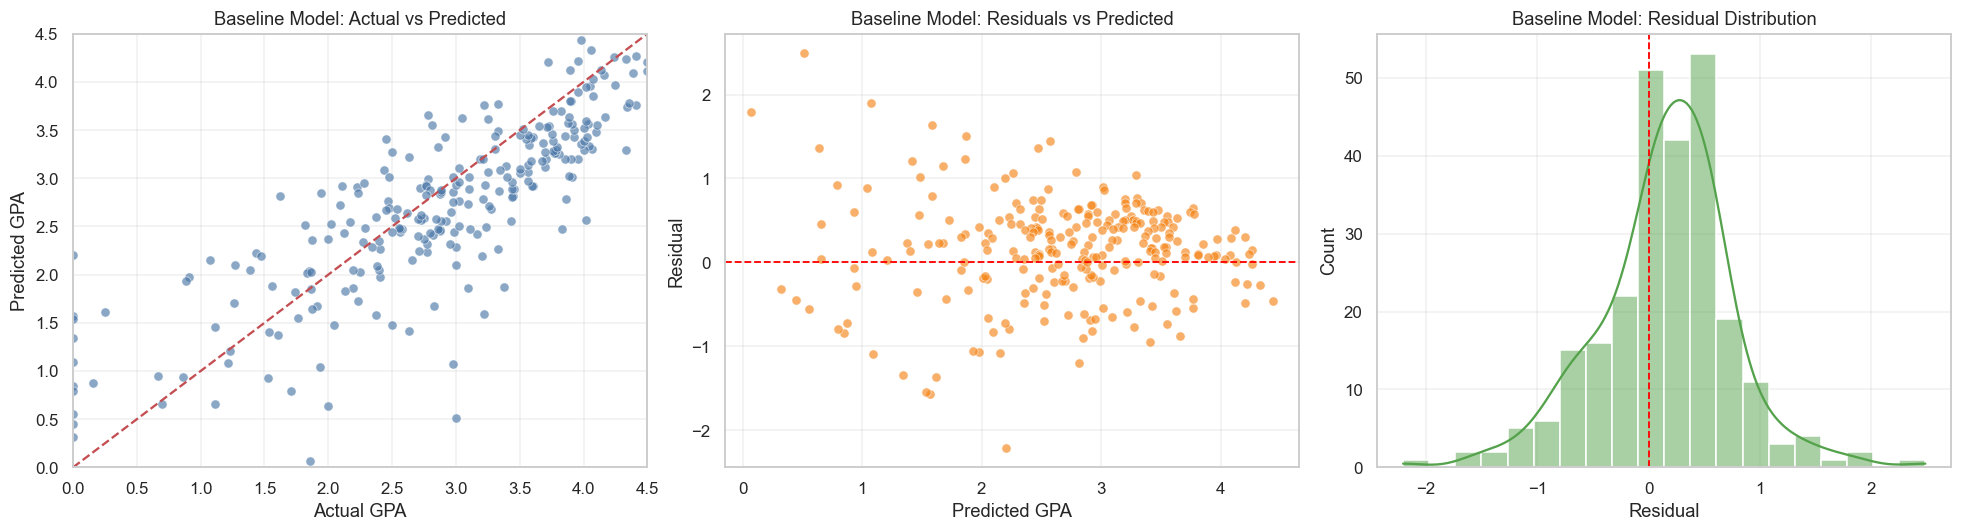

In [67]:
plot_prediction_diagnostics(baseline_test_df, title_prefix='Baseline Model')

### Experiment 2: Baseline Model - RNN with Bayesian Imputation

In [22]:
X_train_rnn = np.array(X_train).reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_rnn = np.array(X_val).reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_rnn = np.array(X_test).reshape(X_test.shape[0], X_test.shape[1], 1)

X_train_rnn = np.asarray(X_train_rnn).astype(np.float32)
X_val_rnn = np.asarray(X_val_rnn).astype(np.float32)
X_test_rnn = np.asarray(X_test_rnn).astype(np.float32)

y_train_rnn = np.asarray(y_train).astype(np.float32)
y_val_rnn = np.asarray(y_val).astype(np.float32)
y_test_rnn = np.asarray(y_test).astype(np.float32)

print(X_train_rnn.shape)   #

(893, 37, 1)


In [23]:
#build rnn model for based model above
from tensorflow.keras.layers import SimpleRNN, Input

baseline_rnn = Sequential([
    Input(shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    SimpleRNN(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    SimpleRNN(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    SimpleRNN(32, activation='tanh'),
    Dense(1)
])

baseline_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 37, 128)             │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 37, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 37, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_1 (SimpleRNN)             │ (None, 37, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 37, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 37, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 32)                  │           3,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 32,897 (128.50 KB)

 Trainable params: 32,513 (127.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [24]:
baseline_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
)

es_rnn, mc_rnn = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'rnn_ baseline_model.keras'
)   

In [25]:
history_rnn = baseline_rnn.fit(
    X_train_rnn, y_train_rnn,
    validation_data=(X_val_rnn, y_val_rnn),
    epochs=100,
    batch_size=32,
    callbacks = [es_rnn, mc_rnn],
    verbose=1
)

Epoch 1/100
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.5163 - mae: 0.5441 - r2: -7.6077 - rmse: 0.7030
Epoch 1: val_loss improved from None to 0.07161, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\rnn_ baseline_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\rnn_ baseline_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 0.2949 - mae: 0.4128 - r2: -3.4770 - rmse: 0.5431 - val_loss: 0.0716 - val_mae: 0.2020 - val_r2: -0.2270 - val_rmse: 0.2676
Epoch 2/100
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1018 - mae: 0.2519 - r2: -0.5670 - rmse: 0.3189
Epoch 2: val_loss improved from 0.07161 to 0.03552, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\rnn_ baseline_model

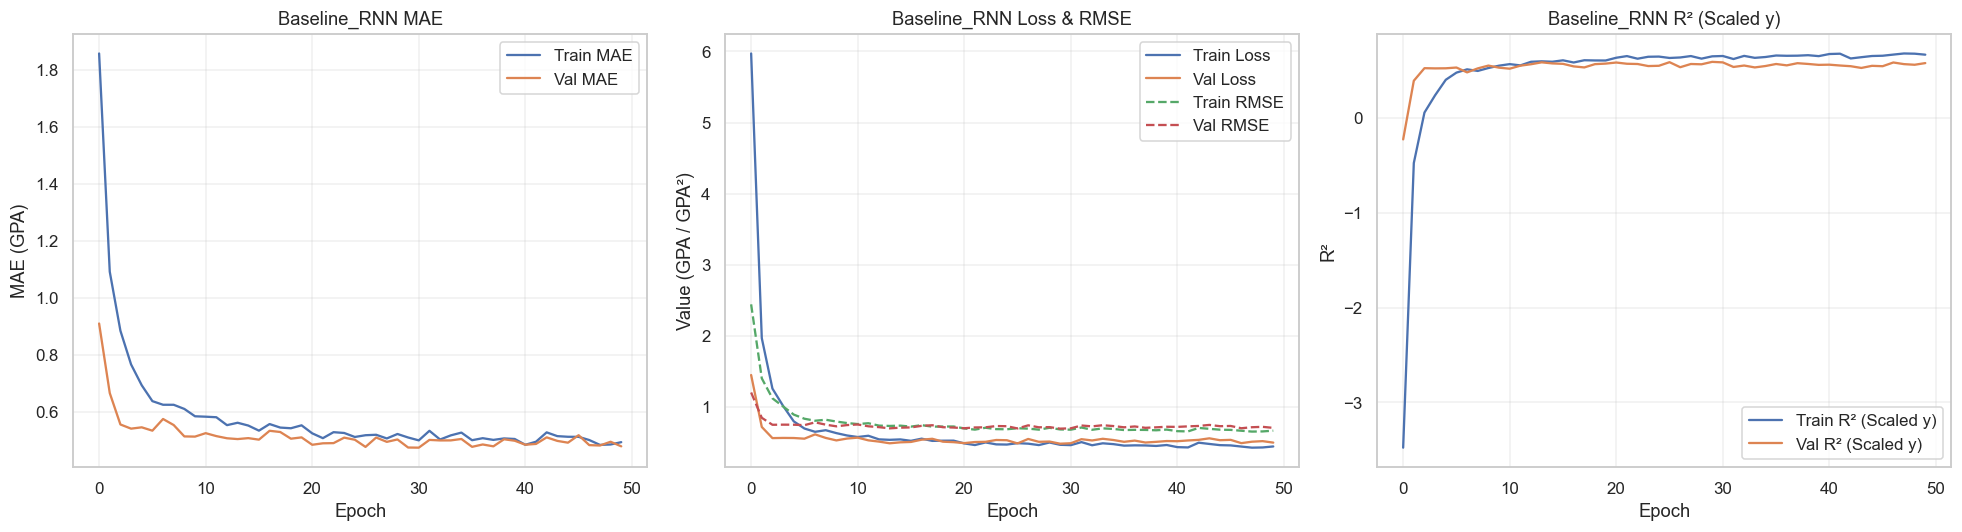


Best Epoch: 30
----------------------------------------
MAE (GPA)   -> Train: 0.5087 | Val: 0.4735
RMSE (GPA)  -> Train: 0.6844 | Val: 0.6956
Loss (GPA²) -> Train: 0.4683 | Val: 0.4838
R² (Scaled y) -> Train: 0.6489 | Val: 0.5906


In [26]:
plot_regression_history(history_rnn, title_prefix='Baseline_RNN')

In [27]:
baseline_rnn_val_metrics, baseline_rnn_val_df = evaluate_model_original_scale(
    baseline_rnn, X_val_rnn, y_val_rnn, scaler, split_name='Baseline RNN Validation'
)
baseline_rnn_test_metrics, baseline_rnn_test_df = evaluate_model_original_scale(
    baseline_rnn, X_test_rnn, y_test_rnn, scaler, split_name='Baseline RNN Test'
)

baseline_rnn_summary_df = pd.DataFrame([baseline_rnn_val_metrics, baseline_rnn_test_metrics]).set_index('split')
display(format_metrics_display(baseline_rnn_summary_df))
display(baseline_rnn_test_df.head(15))

Baseline RNN Validation RMSE: 0.6956
Baseline RNN Validation MSE:  0.4838
Baseline RNN Validation MAE:              0.4735
Baseline RNN Validation R² (Original GPA): 0.5906
Baseline RNN Validation R² (Scaled y):     0.5906
Baseline RNN Test RMSE: 0.6128
Baseline RNN Test MSE:  0.3755
Baseline RNN Test MAE:              0.4621
Baseline RNN Test R² (Original GPA): 0.6596
Baseline RNN Test R² (Scaled y):     0.6596


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline RNN Validation,0.695574,0.483823,0.473483,0.590605,0.590605
Baseline RNN Test,0.612803,0.375527,0.462066,0.659613,0.659613


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.000000,0.756365,2.243635,2.243635,5.033899
1,2.978261,0.943599,2.034662,2.034662,4.139850
2,0.000000,1.969583,-1.969583,1.969583,3.879256
3,0.000000,1.798891,-1.798891,1.798891,3.236010
4,0.000000,1.737322,-1.737322,1.737322,3.018287
5,3.222222,1.520366,1.701855,1.701855,2.896312
6,0.250000,1.916261,-1.666261,1.666261,2.776426
7,1.269231,2.907753,-1.638522,1.638522,2.684754
8,1.857143,0.366314,1.490829,1.490829,2.222572
9,3.095238,1.629482,1.465756,1.465756,2.148442


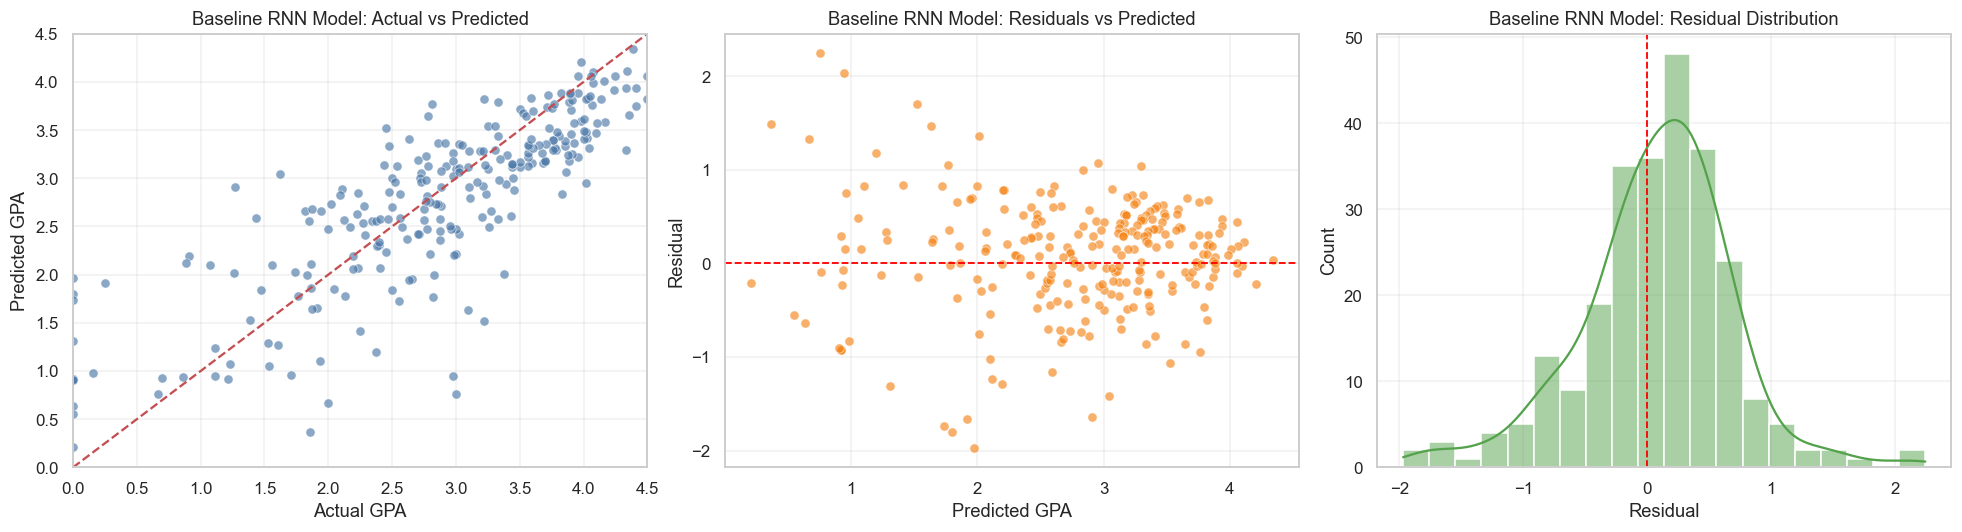

In [28]:
_, baseline_rnn_diag_df = evaluate_and_plot_diagnostics(
    baseline_rnn,
    X_test_rnn,
    y_test_rnn,
    scaler,
    split_name='Baseline RNN Test',
    title_prefix='Baseline RNN Model',
    print_summary=False,
)

### Experiment 3: Baseline Model - LSTM with Bayesian Imputation

In [29]:
from tensorflow.keras.layers import  LSTM

# make sure dtype is numeric
X_train_lstm = np.asarray(X_train, dtype=np.float32).reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_lstm   = np.asarray(X_val, dtype=np.float32).reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_lstm  = np.asarray(X_test, dtype=np.float32).reshape(X_test.shape[0], X_test.shape[1], 1)

y_train_lstm = np.asarray(y_train, dtype=np.float32)
y_val_lstm   = np.asarray(y_val, dtype=np.float32)
y_test_lstm  = np.asarray(y_test, dtype=np.float32)


In [30]:
baseline_lstm = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),

    LSTM(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(32, activation='tanh'),
    Dense(1)
])

baseline_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 37, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 37, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 37, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 37, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 37, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 37, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 129,185 (504.63 KB)

 Trainable params: 128,801 (503.13 KB)

 Non-trainable params: 384 (1.50 KB)

In [31]:
baseline_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
)

es_lstm, mc_lstm = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'lstm_baseline_model.keras'
)

history_lstm = baseline_lstm.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=100,
    batch_size=32,
    callbacks=[es_lstm, mc_lstm],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0953 - mae: 0.2367 - r2: -0.3522 - rmse: 0.3020
Epoch 1: val_loss improved from None to 0.37639, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\lstm_baseline_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\lstm_baseline_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - loss: 0.0566 - mae: 0.1773 - r2: 0.1414 - rmse: 0.2378 - val_loss: 0.3764 - val_mae: 0.5738 - val_r2: -5.4494 - val_rmse: 0.6135
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0315 - mae: 0.1348 - r2: 0.5072 - rmse: 0.1775
Epoch 2: val_loss did not improve from 0.37639
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - loss: 0.0332 - mae: 0.1357 - r2: 0.4953 - rmse: 0.1823 - val_loss: 0.3816 - val_mae: 0.5795 - val_r2: -5.5387 - val_rmse:

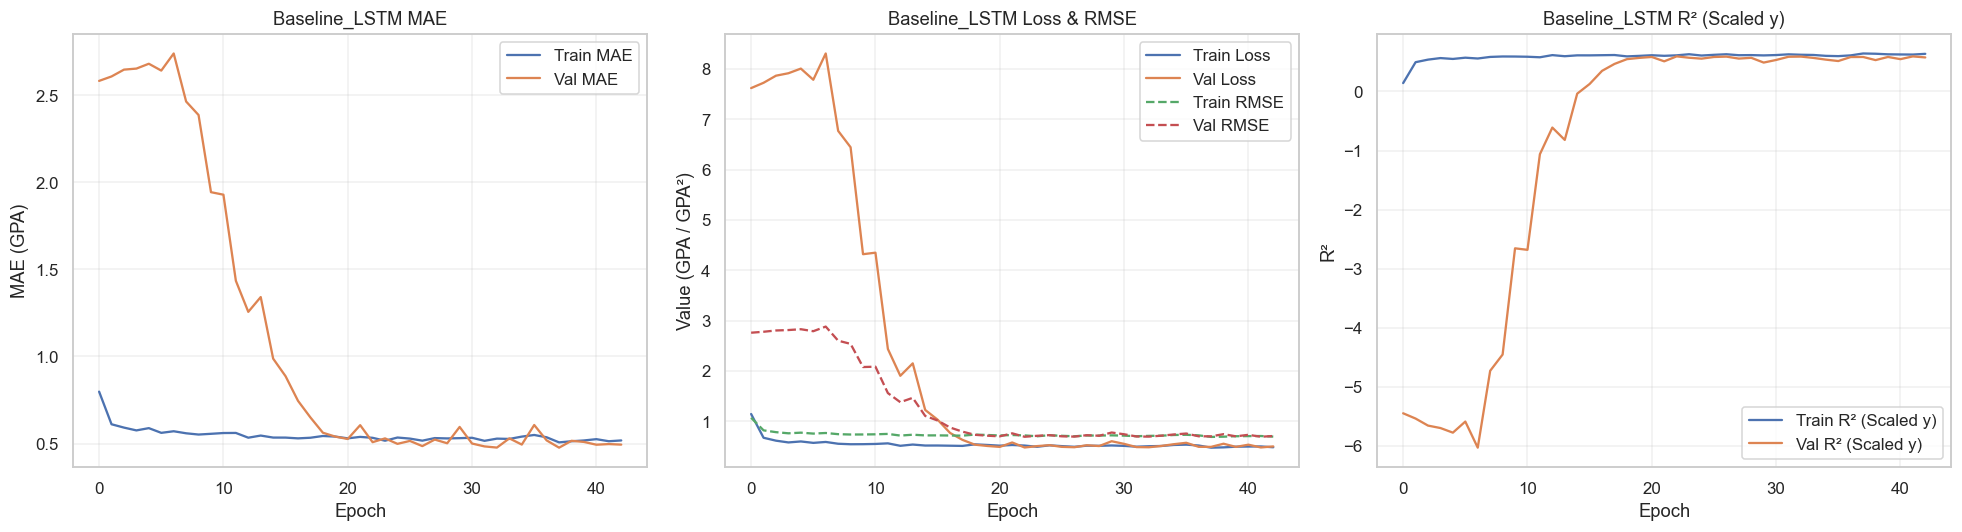


Best Epoch: 23
----------------------------------------
MAE (GPA)   -> Train: 0.5326 | Val: 0.5076
RMSE (GPA)  -> Train: 0.7200 | Val: 0.6928
Loss (GPA²) -> Train: 0.5184 | Val: 0.4799
R² (Scaled y) -> Train: 0.6114 | Val: 0.5939


In [32]:
plot_regression_history(history_lstm, title_prefix='Baseline_LSTM')

In [33]:
baseline_lstm_val_metrics, baseline_lstm_val_df = evaluate_model_original_scale(
    baseline_lstm, X_val_lstm, y_val_lstm, scaler, split_name='Baseline LSTM Validation'
)
baseline_lstm_test_metrics, baseline_lstm_test_df = evaluate_model_original_scale(
    baseline_lstm, X_test_lstm, y_test_lstm, scaler, split_name='Baseline LSTM Test'
)

baseline_lstm_summary_df = pd.DataFrame([baseline_lstm_val_metrics, baseline_lstm_test_metrics]).set_index('split')
display(format_metrics_display(baseline_lstm_summary_df))
display(baseline_lstm_test_df.head(15))

Baseline LSTM Validation RMSE: 0.6928
Baseline LSTM Validation MSE:  0.4799
Baseline LSTM Validation MAE:              0.5076
Baseline LSTM Validation R² (Original GPA): 0.5939
Baseline LSTM Validation R² (Scaled y):     0.5939
Baseline LSTM Test RMSE: 0.5971
Baseline LSTM Test MSE:  0.3565
Baseline LSTM Test MAE:              0.4726
Baseline LSTM Test R² (Original GPA): 0.6768
Baseline LSTM Test R² (Scaled y):     0.6768


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline LSTM Validation,0.692768,0.479928,0.507628,0.593901,0.593901
Baseline LSTM Test,0.597117,0.356549,0.472624,0.676816,0.676816


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.250000,2.304435,-2.054435,2.054435,4.220704
1,0.000000,1.800907,-1.800907,1.800907,3.243265
2,0.000000,1.747771,-1.747771,1.747771,3.054705
3,0.000000,1.684064,-1.684064,1.684064,2.836072
4,0.000000,1.550610,-1.550610,1.550610,2.404391
5,4.333333,2.799736,1.533597,1.533597,2.351921
6,3.000000,1.524748,1.475252,1.475252,2.176369
7,1.619048,3.087019,-1.467971,1.467971,2.154938
8,0.000000,1.351426,-1.351426,1.351426,1.826353
9,0.000000,1.332996,-1.332996,1.332996,1.776877


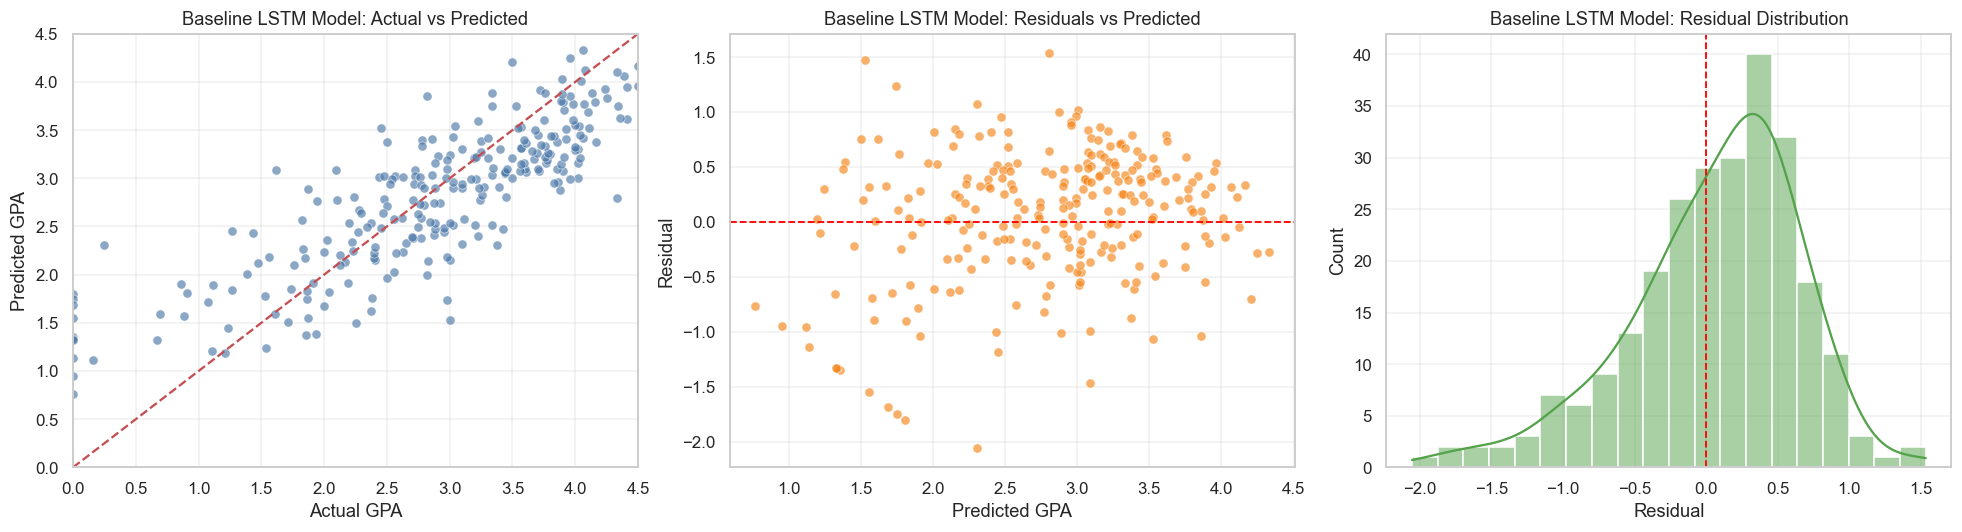

In [34]:
_, baseline_lstm_diag_df = evaluate_and_plot_diagnostics(
    baseline_lstm,
    X_test_lstm,
    y_test_lstm,
    scaler,
    split_name='Baseline LSTM Test',
    title_prefix='Baseline LSTM Model',
    print_summary=False,
)

### Experiment 4: Keras Tuner - Automatic Hyperband Search for LSTM Based on Baseline Results

In [35]:
def build_tuner_model(hp):
    num_layers = hp.Int('num_layers', 1, 5)
    layer_specs = [{'units': hp.Choice(f'neurons_{i}', [64, 128, 256, 512, 1024]),
                    'activation': hp.Choice(f'act_{i}', ['relu', 'tanh', 'elu']),
                    'dropout': hp.Float(f'dropout_{i}', 0.1, 0.5, step=0.1)} for i in range(num_layers)]

    tuner_model = Sequential([Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
                              LSTM(layer_specs[0]['units'], activation=layer_specs[0]['activation'], return_sequences=(num_layers > 1)),
                              BatchNormalization(),
                              Dropout(layer_specs[0]['dropout'])])

    for i in range(1, num_layers):
        tuner_model.add(LSTM(layer_specs[i]['units'], activation=layer_specs[i]['activation'], return_sequences=(i < num_layers - 1)))
        tuner_model.add(BatchNormalization())
        tuner_model.add(Dropout(layer_specs[i]['dropout']))

    tuner_model.add(Dense(1))
    return compile_regression_model(
        tuner_model,
        optimizer_name=hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop']),
        learning_rate=hp.Choice('learning_rate', [0.0001, 0.0005, 0.001, 0.002, 0.003, 0.004, 0.005, 0.01])
    )


def show_best_hyperparameters(hyperparameters):
    rows = [{'hyperparameter': k, 'value': v} for k, v in hyperparameters.values.items()]
    display(pd.DataFrame(rows))

In [75]:
tuner_dir = project_path / 'second_term_gpa_regression' / 'tuner' / 'student_tuner'
if tuner_dir.exists():
    shutil.rmtree(tuner_dir, ignore_errors=True)

print_header('KERAS TUNER SEARCH')

hyperband_tuner = Hyperband(
    hypermodel=build_tuner_model,
    objective='val_loss',
    max_epochs=40,
    factor=3,
    directory=tuner_dir,
    project_name='student_tuner',
    seed=42,
    overwrite=True,
)

search_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0,
    mode='min',
)

search_start = time.time()
hyperband_tuner.search(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=60,
    callbacks=[search_stop],
    verbose=1,
)
search_time = time.time() - search_start

print(f'Search completed in {search_time / 60:.1f} minutes')
hyperband_tuner.results_summary(num_trials=10)

best_hps = hyperband_tuner.get_best_hyperparameters(1)[0]
print_header('BEST HYPERPARAMETERS')
show_best_hyperparameters(best_hps)

Trial 71 Complete [00h 04m 07s]
val_loss: 0.02605978399515152

Best val_loss So Far: 0.02405337058007717
Total elapsed time: 03h 21m 51s
Search completed in 201.9 minutes
Results summary
Results in C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\tuner\student_tuner\student_tuner
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0066 summary
Hyperparameters:
num_layers: 1
neurons_0: 128
act_0: elu
dropout_0: 0.2
optimizer: adam
learning_rate: 0.01
neurons_1: 512
act_1: relu
dropout_1: 0.1
neurons_2: 64
act_2: elu
dropout_2: 0.2
neurons_3: 64
act_3: relu
dropout_3: 0.30000000000000004
neurons_4: 64
act_4: relu
dropout_4: 0.2
tuner/epochs: 40
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.02405337058007717

Trial 0070 summary
Hyperparameters:
num_layers: 1
neurons_0: 256
act_0: tanh
dropout_0: 0.30000000000000004
optimizer: adam
learning_rate: 0.01
neurons_1: 64
act_1: relu
dropout

,hyperparameter,value
0,num_layers,1
1,neurons_0,128
2,act_0,elu
3,dropout_0,0.2
4,optimizer,adam
5,learning_rate,0.01
6,neurons_1,512
7,act_1,relu
8,dropout_1,0.1
9,neurons_2,64


### Hyperband Results

In [77]:
all_trials = list(hyperband_tuner.oracle.trials.values())

target_scale = get_target_scale(scaler)
mse_scale = target_scale ** 2

rows = []
for t in all_trials:
    hp = t.hyperparameters.values

    num_layers = hp.get('num_layers', 0)
    layer_parts = []

    for i in range(num_layers):
        neurons = hp.get(f'neurons_{i}')
        act = hp.get(f'act_{i}')
        drop = hp.get(f'dropout_{i}')
        layer_parts.append(f"{neurons}-{act}-Drop{drop}")

    architecture = f"{num_layers}L-" + "-".join(layer_parts)
    experiment = f"{architecture}-{hp.get('optimizer')}-LR{hp.get('learning_rate')}"

    rows.append({
        'Experiment': experiment,
        'Loss (GPA²)': (t.metrics.metrics['loss'].get_best_value() * mse_scale) if 'loss' in t.metrics.metrics else None,
        'Val_Loss (GPA²)': (t.metrics.metrics['val_loss'].get_best_value() * mse_scale) if 'val_loss' in t.metrics.metrics else None,
        'MAE (GPA)': (t.metrics.metrics['mae'].get_best_value() * target_scale) if 'mae' in t.metrics.metrics else None,
        'Val_MAE (GPA)': (t.metrics.metrics['val_mae'].get_best_value() * target_scale) if 'val_mae' in t.metrics.metrics else None,
        'RMSE (GPA)': (t.metrics.metrics['rmse'].get_best_value() * target_scale) if 'rmse' in t.metrics.metrics else None,
        'Val_RMSE (GPA)': (t.metrics.metrics['val_rmse'].get_best_value() * target_scale) if 'val_rmse' in t.metrics.metrics else None,
        'R2': t.metrics.metrics['r2'].get_best_value() if 'r2' in t.metrics.metrics else None,
        'Val_R2': t.metrics.metrics['val_r2'].get_best_value() if 'val_r2' in t.metrics.metrics else None,
        'Epochs': hp.get('tuner/epochs'),
        'Trial_ID': t.trial_id
    })

tuning_results_df = pd.DataFrame(rows).sort_values('Val_Loss (GPA²)').reset_index(drop=True)
tuning_results_df.insert(0, '#', range(1, len(tuning_results_df) + 1))

tuning_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'keras_tuner_results_comb_regression_bayesian.csv',
    index=False,
)

display_df = tuning_results_df.head(20).copy()

for col in ['Loss (GPA²)', 'Val_Loss (GPA²)', 'MAE (GPA)', 'Val_MAE (GPA)', 'RMSE (GPA)', 'Val_RMSE (GPA)', 'R2', 'Val_R2']:
    display_df[col] = display_df[col].map(lambda x: f"{x:.4f}" if pd.notnull(x) else "")

print("=" * 160)
print("TOP 20 BEST TRIALS (loss/MAE/RMSE in original GPA scale, R² in scaled y)")
print("=" * 160)
print(display_df.to_string(index=False))

TOP 20 BEST TRIALS (loss/MAE/RMSE in original GPA scale, R² in scaled y)
 #                                                                                          Experiment Loss (GPA²) Val_Loss (GPA²) MAE (GPA) Val_MAE (GPA) RMSE (GPA) Val_RMSE (GPA)      R2 Val_R2  Epochs Trial_ID
 1                                                                      1L-128-elu-Drop0.2-adam-LR0.01      0.5448          0.4871    0.5672        0.5179     0.7381         0.6979  0.5915 0.5878      40     0066
 2                                                     1L-256-tanh-Drop0.30000000000000004-adam-LR0.01      0.5389          0.5277    0.5556        0.5135     0.7341         0.7264  0.5960 0.5535      40     0070
 3                                                   2L-512-tanh-Drop0.5-128-tanh-Drop0.2-adam-LR0.003      0.7184          0.5987    0.6528        0.5958     0.8476         0.7737  0.4614 0.4934      40     0068
 4                                                    2L-256-elu-Drop0.2-12

In [38]:
from keras_tuner import Hyperband

reload_tuner = Hyperband(
    hypermodel=build_tuner_model,
    objective='val_loss',
    max_epochs=40,
    factor=3,
    directory=project_path / 'second_term_gpa_regression' / 'tuner' / 'student_tuner',
    project_name='student_tuner',
    seed=42,
    overwrite=False,
)

reload_tuner.reload()

# best_model = hyperband_tuner.hypermodel.build(best_hps)
best_model = reload_tuner.get_best_models(num_models=1)[0]
best_model.summary()

best_es, best_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'best_regression_model_bayesian.keras',
)

history_best = best_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=200,
    callbacks=[best_es, best_mc],
    verbose=1,
)

print('Training completed.')

Reloading Tuner from C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\tuner\student_tuner\student_tuner\tuner0.json



C:\Vivek\Soft\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 128)                 │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 67,201 (262.50 KB)

 Trainable params: 66,945 (261.50 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/200
27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.6645 - mae: 0.3394 - r2: -8.6970 - rmse: 0.7508
Epoch 1: val_loss improved from None to 0.28957, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_regression_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - loss: 0.2467 - mae: 0.2145 - r2: -2.7457 - rmse: 0.4967 - val_loss: 0.2896 - val_mae: 0.5086 - val_r2: -3.9618 - val_rmse: 0.5381
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0330 - mae: 0.1442 - r2: 0.4904 - rmse: 0.1815
Epoch 2: val_loss did not improve from 0.28957
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0323 - mae: 0.1404 - r2: 0.5098 - rmse: 0.1797 - val_loss: 1.2577 - val_mae: 1.1088 - val_r2

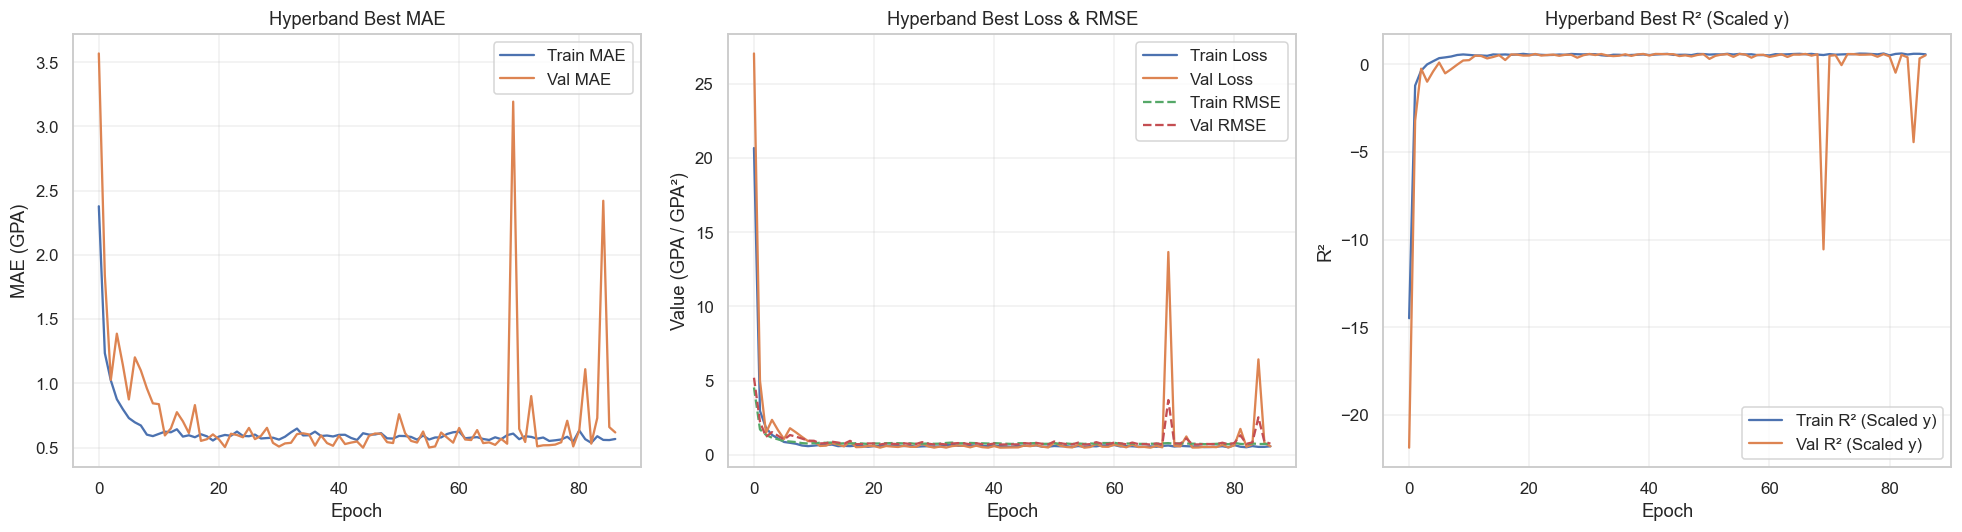


Best Epoch: 67
----------------------------------------
MAE (GPA)   -> Train: 0.5798 | Val: 0.5207
RMSE (GPA)  -> Train: 0.7617 | Val: 0.7012
Loss (GPA²) -> Train: 0.5802 | Val: 0.4917
R² (Scaled y) -> Train: 0.5651 | Val: 0.5840


In [ ]:
plot_regression_history(history_best, title_prefix='Hyperband Best')

In [ ]:
best_val_metrics, best_val_df = evaluate_model_original_scale(
    best_model, X_val_lstm, y_val_lstm, scaler, split_name='Hyperband Validation'
)
best_test_metrics, best_test_df = evaluate_model_original_scale(
    best_model, X_test_lstm, y_test_lstm, scaler, split_name='Hyperband Test'
)

best_summary_df = pd.DataFrame([best_val_metrics, best_test_metrics]).set_index('split')
display(format_metrics_display(best_summary_df))
display(best_test_df.head(15))

Hyperband Validation RMSE: 0.6925
Hyperband Validation MSE:  0.4796
Hyperband Validation MAE:              0.4723
Hyperband Validation R² (Original GPA): 0.5942
Hyperband Validation R² (Scaled y):     0.5942
Hyperband Test RMSE: 0.5759
Hyperband Test MSE:  0.3317
Hyperband Test MAE:              0.4441
Hyperband Test R² (Original GPA): 0.6994
Hyperband Test R² (Scaled y):     0.6994


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Hyperband Validation,0.692515,0.479577,0.472309,0.594198,0.594198
Hyperband Test,0.575908,0.331670,0.444145,0.699366,0.699366


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.000000,1.073042,1.926958,1.926958,3.713167
1,0.000000,1.822090,-1.822090,1.822090,3.320011
2,0.250000,2.037402,-1.787402,1.787402,3.194807
3,0.000000,1.732766,-1.732766,1.732766,3.002477
4,0.000000,1.655517,-1.655517,1.655517,2.740735
5,1.269231,2.845322,-1.576091,1.576091,2.484064
6,1.619048,3.171150,-1.552102,1.552102,2.409020
7,0.000000,1.444468,-1.444468,1.444468,2.086489
8,2.978261,1.620066,1.358195,1.358195,1.844693
9,3.375000,2.102654,1.272346,1.272346,1.618863


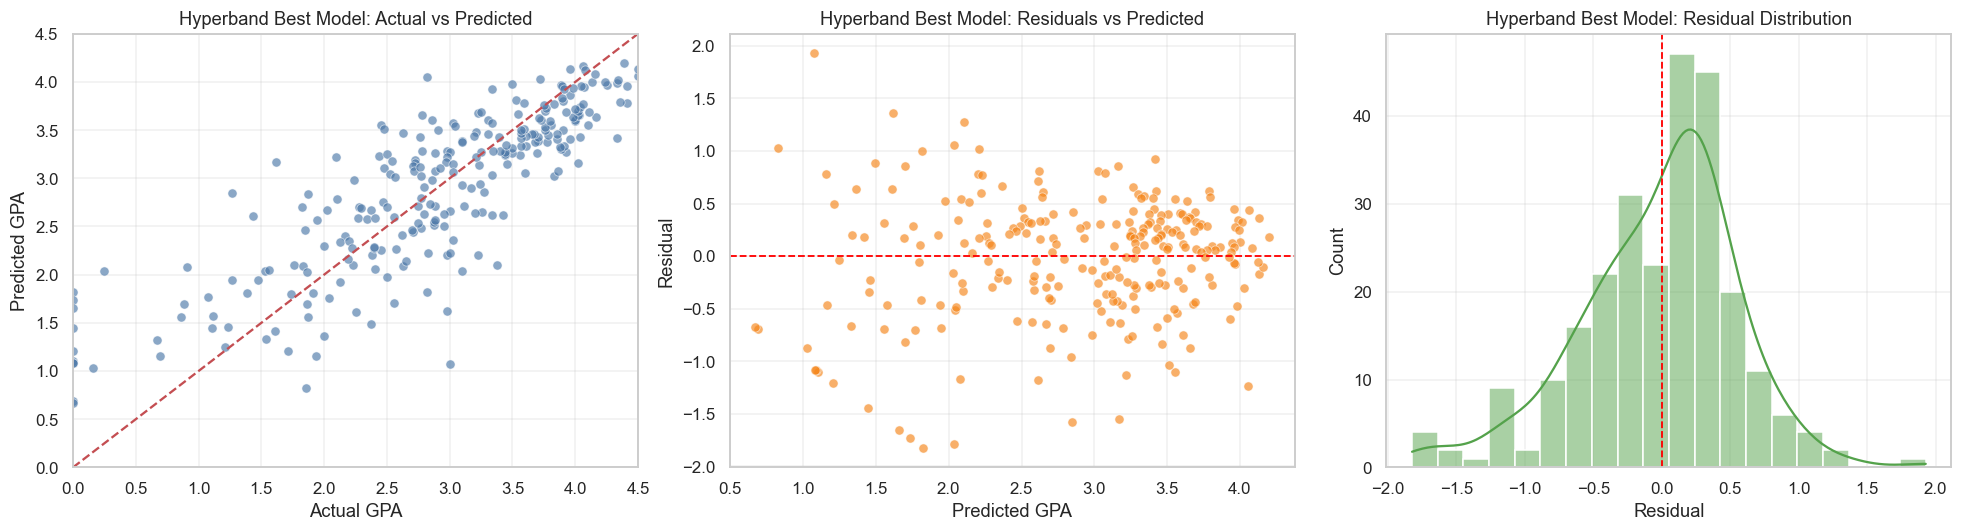

In [40]:
plot_prediction_diagnostics(best_test_df, title_prefix='Hyperband Best Model')

### Experiment 5: Custom Model based on Hyperband Findings

In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization

custom_layers = [
    {'units': 512, 'dropout': 0.1},
    {'units': 128, 'dropout': 0.2},
]

custom_model = Sequential([
      Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
])

# Add LSTM layers
for i, spec in enumerate(custom_layers):
    return_seq = i < len(custom_layers) - 1  # True for all except last layer
    
    custom_model.add(LSTM(spec['units'], return_sequences=return_seq))
    
    custom_model.add(BatchNormalization())
    
    if spec.get('dropout', 0.0) > 0:
        custom_model.add(Dropout(spec['dropout']))

# Output layer (regression)
custom_model.add(Dense(1))

custom_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_23 (LSTM)                       │ (None, 37, 512)             │       1,052,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_25               │ (None, 37, 512)             │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 37, 512)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_24 (LSTM)                       │ (None, 128)                 │         328,192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_26               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,383,553 (5.28 MB)

 Trainable params: 1,382,273 (5.27 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [80]:
custom_model = compile_regression_model(custom_model, optimizer_name='sgd', learning_rate=0.0009)

custom_es, custom_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'custom_model_bayesian.keras',
)

history_custom = custom_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=200,
    callbacks=[custom_es, custom_mc],
    verbose=1,
)

Epoch 1/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 1.3549 - mae: 0.8930 - r2: -20.1380 - rmse: 1.1520
Epoch 1: val_loss improved from None to 0.09731, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_bayesian.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_model_bayesian.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 267ms/step - loss: 0.9172 - mae: 0.7308 - r2: -12.9247 - rmse: 0.9577 - val_loss: 0.0973 - val_mae: 0.2724 - val_r2: -0.6674 - val_rmse: 0.3119
Epoch 2/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 0.4523 - mae: 0.5206 - r2: -6.1741 - rmse: 0.6721
Epoch 2: val_loss improved from 0.09731 to 0.05950, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\custom_mo

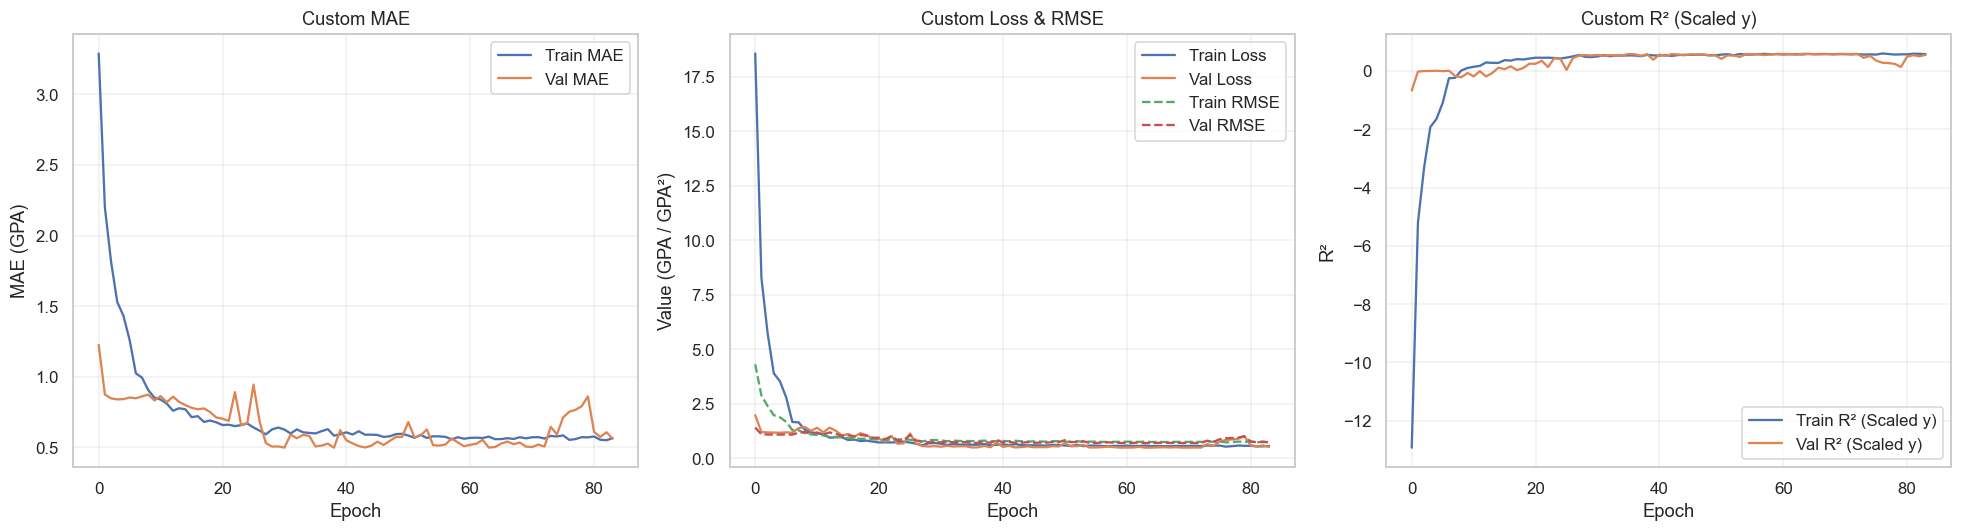


Best Epoch: 64
----------------------------------------
MAE (GPA)   -> Train: 0.5769 | Val: 0.4994
RMSE (GPA)  -> Train: 0.7588 | Val: 0.6954
Loss (GPA²) -> Train: 0.5758 | Val: 0.4836
R² (Scaled y) -> Train: 0.5684 | Val: 0.5908


In [83]:
plot_regression_history(history_custom, title_prefix='Custom')

In [84]:
custom_val_metrics, custom_val_df = evaluate_model_original_scale(
    custom_model, X_val_lstm, y_val_lstm, scaler, split_name='Custom Validation'
)
custom_test_metrics, custom_test_df = evaluate_model_original_scale(
    custom_model, X_test_lstm, y_test_lstm, scaler, split_name='Custom Test'
)

custom_summary_df = pd.DataFrame([custom_val_metrics, custom_test_metrics]).set_index('split')
display(format_metrics_display(custom_summary_df))
display(custom_test_df.head(15))

Custom Validation RMSE: 0.6954
Custom Validation MSE:  0.4836
Custom Validation MAE:              0.4994
Custom Validation R² (Original GPA): 0.5908
Custom Validation R² (Scaled y):     0.5908
Custom Test RMSE: 0.5936
Custom Test MSE:  0.3524
Custom Test MAE:              0.4626
Custom Test R² (Original GPA): 0.6806
Custom Test R² (Scaled y):     0.6806


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Custom Validation,0.695401,0.483583,0.499435,0.590808,0.590808
Custom Test,0.593619,0.352384,0.462558,0.680591,0.680591


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.250000,2.252425,-2.002425,2.002425,4.009706
1,0.000000,1.863564,-1.863564,1.863564,3.472872
2,1.619048,3.369238,-1.750190,1.750190,3.063165
3,3.000000,1.409205,1.590795,1.590795,2.530630
4,0.000000,1.506231,-1.506231,1.506231,2.268731
5,0.000000,1.504601,-1.504601,1.504601,2.263824
6,2.978261,1.515868,1.462393,1.462393,2.138592
7,0.000000,1.453836,-1.453836,1.453836,2.113638
8,0.000000,1.335115,-1.335115,1.335115,1.782531
9,4.333333,3.003579,1.329754,1.329754,1.768247


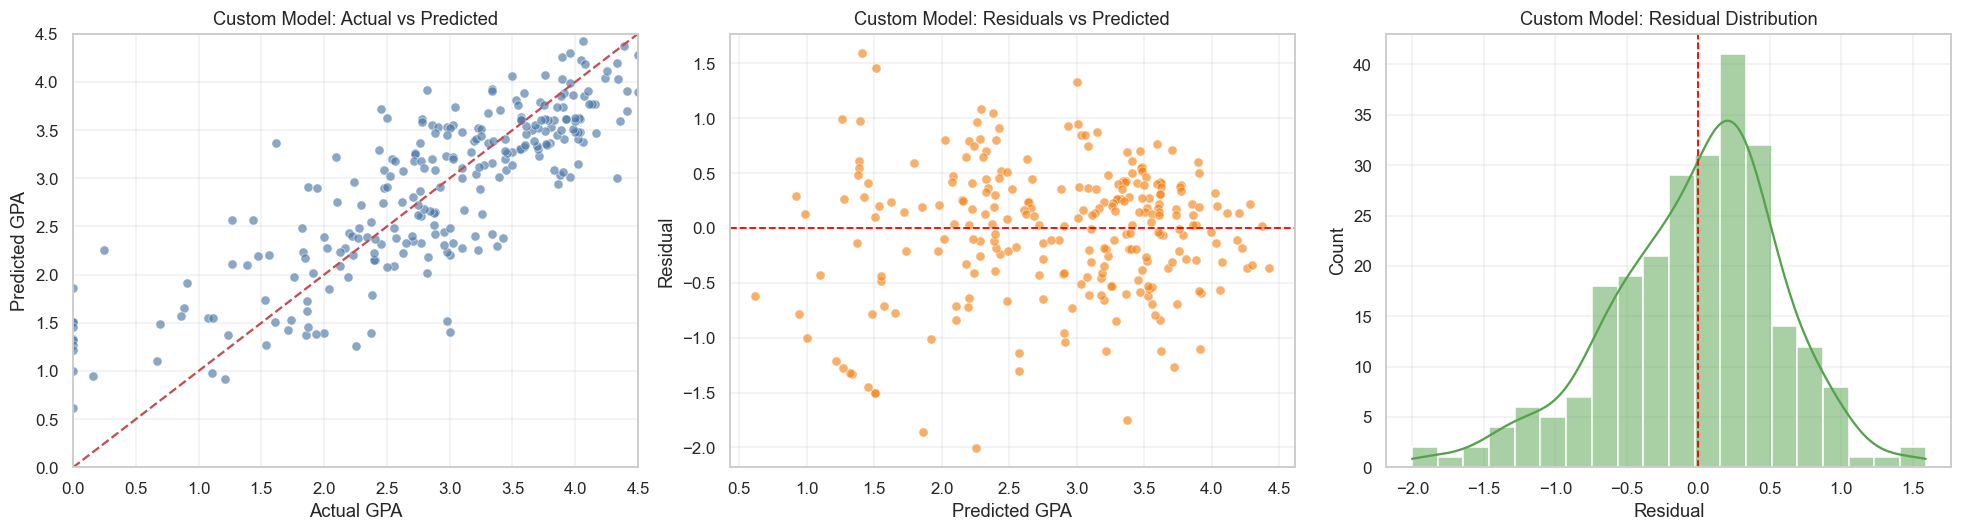

In [85]:
plot_prediction_diagnostics(custom_test_df, title_prefix='Custom Model')

### Experiment 5: Local Search around the Custom Architecture

In [46]:
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense, BatchNormalization

def build_lstm_model(input_shape, layer_specs):
    model = Sequential([
        Input(shape=input_shape)
    ])

    for i, spec in enumerate(layer_specs):
        return_seq = i < len(layer_specs) - 1
        model.add(LSTM(spec['units'], activation=spec.get('activation', 'tanh'), return_sequences=return_seq))
        if spec.get('batch_norm', False):
            model.add(BatchNormalization())
        if spec.get('dropout', 0) > 0:
            model.add(Dropout(spec['dropout']))

    model.add(Dense(1))
    return model

In [47]:
# trying to find the local minimum around the custom model configuration by varying learning rate and batch size

base_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.10},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.20},
]

local_search_configs = [
    {'trial_name': 'SGD-lr0.00085-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00085, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00088-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00088, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00090-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00092-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00092, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00095-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00095, 'batch_size': 64},

    {'trial_name': 'SGD-lr0.00090-bs32', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 32},
    {'trial_name': 'SGD-lr0.00090-bs64', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 64},
    {'trial_name': 'SGD-lr0.00090-bs96', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 96},
    {'trial_name': 'SGD-lr0.00090-bs128', 'layers': base_layers, 'optimizer': 'sgd', 'learning_rate': 0.00090, 'batch_size': 128},
]

local_search_results = []
local_search_models = {}
local_search_histories = {}
best_local_model = None
best_local_history = None
best_local_metrics = None
best_local_config = None
best_local_sort_key = None

for trial_idx, config in enumerate(local_search_configs, start=1):
    print_header(config['trial_name'])

    trial_model = build_lstm_model(X_train_lstm.shape[1:], config['layers'])
    trial_model = compile_regression_model(
        trial_model,
        optimizer_name=config['optimizer'],
        learning_rate=config['learning_rate'],
        clipnorm=1.0,
    )

    trial_es = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1,
        mode='min',
    )

    trial_history = trial_model.fit(
        X_train_lstm, y_train_lstm,
        validation_data=(X_val_lstm, y_val_lstm),
        epochs=200,
        batch_size=config['batch_size'],
        callbacks=[trial_es, TerminateOnNaN()],
        verbose=1,
    )

    non_finite_epoch, non_finite_metric = get_non_finite_history_event(trial_history)
    trial_status = 'completed'
    failure_reason = ''

    try:
        trial_val_metrics, _ = evaluate_model_original_scale(
            trial_model, X_val_lstm, y_val_lstm, scaler, split_name=f"{config['trial_name']} Validation", print_summary=False
        )
        trial_test_metrics, _ = evaluate_model_original_scale(
            trial_model, X_test_lstm, y_test_lstm, scaler, split_name=f"{config['trial_name']} Test", print_summary=False
        )
    except ValueError as exc:
        trial_status = 'failed'
        failure_reason = str(exc)
        if non_finite_epoch is not None:
            failure_reason += f" Training became non-finite at epoch {non_finite_epoch} ({non_finite_metric})."
        print(f"Skipping {config['trial_name']}: {failure_reason}")
        trial_val_metrics = empty_regression_metrics(f"{config['trial_name']} Validation")
        trial_test_metrics = empty_regression_metrics(f"{config['trial_name']} Test")

    best_epoch = get_best_epoch_from_history(trial_history)
    local_result = {
        'trial': trial_idx,
        'trial_name': config['trial_name'],
        'optimizer': config['optimizer'],
        'learning_rate': config['learning_rate'],
        'batch_size': config['batch_size'],
        'best_epoch': best_epoch,
        'status': trial_status,
        'failure_reason': failure_reason,
        'val_rmse': trial_val_metrics['rmse'],
        'val_mae': trial_val_metrics['mae'],
        'val_r2_original': trial_val_metrics['r2_original'],
        'val_r2_scaled': trial_val_metrics['r2_scaled'],
        'test_rmse': trial_test_metrics['rmse'],
        'test_mae': trial_test_metrics['mae'],
        'test_r2_original': trial_test_metrics['r2_original'],
        'test_r2_scaled': trial_test_metrics['r2_scaled'],
        'architecture': ' | '.join([f"{layer['units']}:{layer['activation']}" for layer in config['layers']]),
    }
    local_search_results.append(local_result)
    local_search_models[f"{trial_idx:02d}_{config['trial_name']}"] = trial_model
    local_search_histories[f"{trial_idx:02d}_{config['trial_name']}"] = trial_history

    if trial_status == 'completed':
        sort_key = (trial_val_metrics['r2_original'], -trial_val_metrics['rmse'])
        if best_local_sort_key is None or sort_key > best_local_sort_key:
            best_local_sort_key = sort_key
            best_local_model = trial_model
            best_local_history = trial_history
            best_local_metrics = local_result
            best_local_config = config

local_search_results_df = pd.DataFrame(local_search_results)
local_search_results_df['sort_status'] = (local_search_results_df['status'] != 'completed').astype(int)
local_search_results_df = local_search_results_df.sort_values(
    ['sort_status', 'val_r2_original', 'val_rmse'],
    ascending=[True, False, True],
    na_position='last',
).drop(columns='sort_status').reset_index(drop=True)
local_search_results_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'local_search_results_regression_bayesian.csv',
    index=False,
)


========================== SGD-lr0.00085-bs64 ==========================

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 432ms/step - loss: 0.9902 - mae: 0.8030 - r2: -14.0319 - rmse: 0.9951 - val_loss: 0.3065 - val_mae: 0.5122 - val_r2: -4.2520 - val_rmse: 0.5536
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 346ms/step - loss: 0.5565 - mae: 0.5892 - r2: -7.4486 - rmse: 0.7460 - val_loss: 0.1283 - val_mae: 0.3181 - val_r2: -1.1979 - val_rmse: 0.3581
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 350ms/step - loss: 0.4838 - mae: 0.5149 - r2: -6.3442 - rmse: 0.6955 - val_loss: 0.0707 - val_mae: 0.2258 - val_r2: -0.2120 - val_rmse: 0.2660
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 360ms/step - loss: 0.3042 - mae: 0.4260 - r2: -3.6178 - rmse: 0.5515 - val_loss: 0.0584 - val_mae: 0.1889 - val_r2: -0.0012 - val_rmse: 0.2417
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 339ms/step - loss: 0.3176 - mae: 0.4097 - r2: -3.8216 - rmse: 0.5636 - val_loss: 0.0597 - val_mae: 0.1853 - val_r2: -0.0222 - val_rmse: 0.244

In [54]:
# Save the best local search model
if best_local_model is None:
    raise RuntimeError("Local search did not produce any successful trials. Inspect local_search_results_df[['trial_name', 'status', 'failure_reason']].")

best_local_model.save(project_path / 'second_term_gpa_regression' / 'models' / 'local_search_model_bayesian.keras')

print('BEST LOCAL SEARCH CONFIG')
for key, value in best_local_config.items():
    print(f"{key}: {value}")

display(format_local_search_display(local_search_results_df))

BEST LOCAL SEARCH CONFIG
trial_name: SGD-lr0.00090-bs32
layers: [{'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1}, {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2}]
optimizer: sgd
learning_rate: 0.0009
batch_size: 32


,Trial,Trial Name,Optimizer,Learning Rate,Batch Size,Best Epoch,Status,Failure Reason,Val RMSE (GPA),Val MAE (GPA),Val R² (Original GPA),Val R² (Scaled y),Test RMSE (GPA),Test MAE (GPA),Test R² (Original GPA),Test R² (Scaled y),Architecture
0,6,SGD-lr0.00090-bs32,sgd,0.00090,32,55,completed,,0.697798,0.513751,0.587982,0.587982,0.594318,0.471711,0.679839,0.679839,516:tanh | 128:elu
1,2,SGD-lr0.00088-bs64,sgd,0.00088,64,78,completed,,0.701304,0.514745,0.583831,0.583831,0.592790,0.471743,0.681483,0.681483,516:tanh | 128:elu
2,8,SGD-lr0.00090-bs96,sgd,0.00090,96,88,completed,,0.701677,0.502121,0.583389,0.583389,0.600904,0.458855,0.672704,0.672704,516:tanh | 128:elu
3,7,SGD-lr0.00090-bs64,sgd,0.00090,64,74,completed,,0.703525,0.522652,0.581192,0.581192,0.601081,0.477432,0.672510,0.672510,516:tanh | 128:elu
4,1,SGD-lr0.00085-bs64,sgd,0.00085,64,65,completed,,0.703623,0.511504,0.581074,0.581074,0.596510,0.467869,0.677473,0.677473,516:tanh | 128:elu
5,5,SGD-lr0.00095-bs64,sgd,0.00095,64,78,completed,,0.704577,0.502098,0.579938,0.579938,0.594857,0.462040,0.679257,0.679257,516:tanh | 128:elu
6,9,SGD-lr0.00090-bs128,sgd,0.00090,128,34,completed,,1.075317,0.833626,0.021571,0.021571,1.036507,0.806077,0.026187,0.026186,516:tanh | 128:elu
7,4,SGD-lr0.00092-bs64,sgd,0.00092,64,11,completed,,1.082099,0.848325,0.009190,0.009190,1.044868,0.819600,0.010412,0.010412,516:tanh | 128:elu
8,3,SGD-lr0.00090-bs64,sgd,0.00090,64,6,completed,,1.085968,0.848214,0.002093,0.002093,1.048740,0.820045,0.003064,0.003064,516:tanh | 128:elu


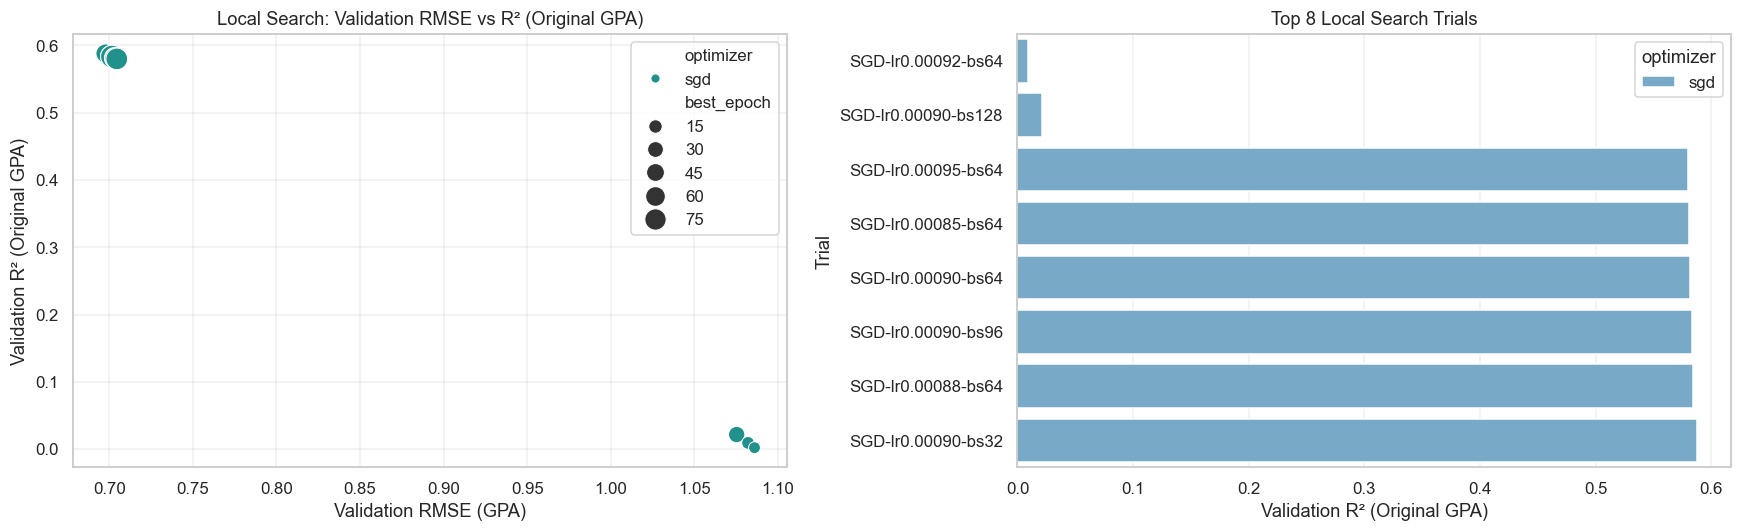

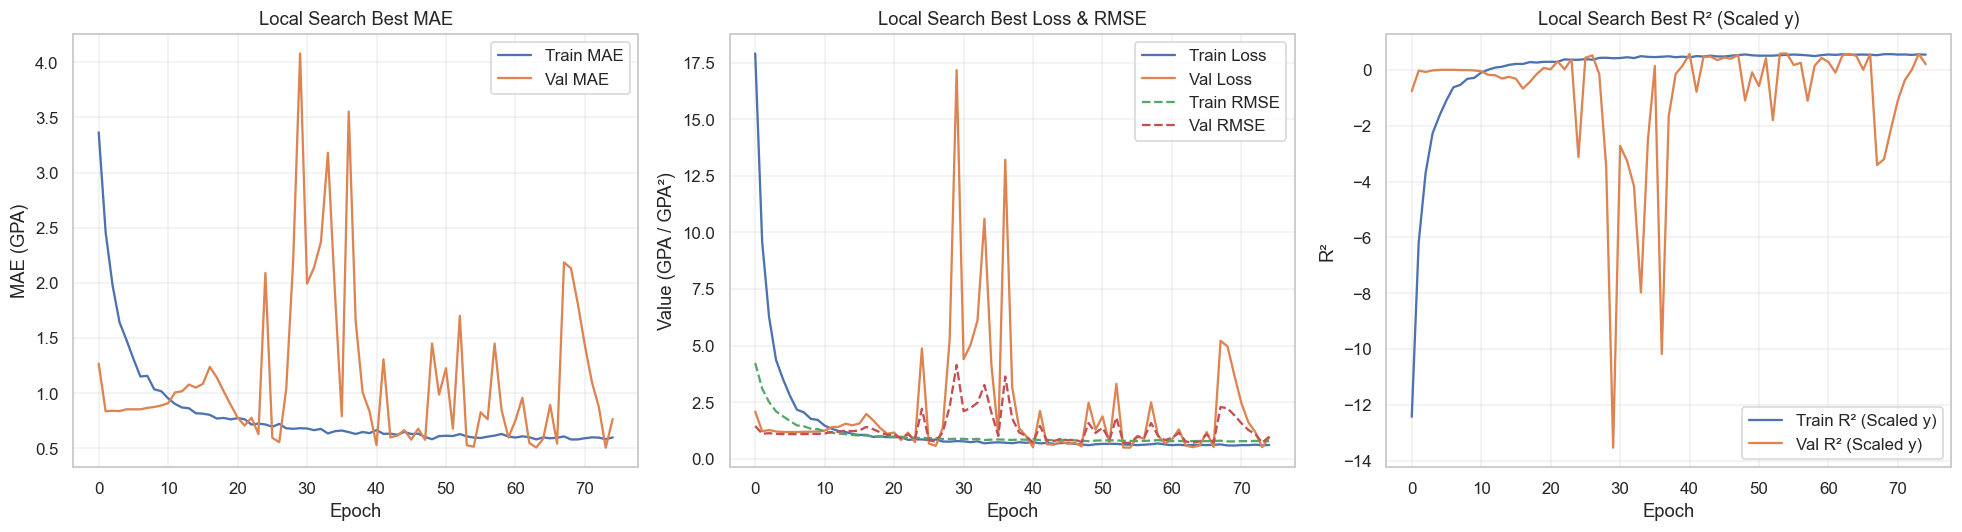


Best Epoch: 55
----------------------------------------
MAE (GPA)   -> Train: 0.5971 | Val: 0.5138
RMSE (GPA)  -> Train: 0.7865 | Val: 0.6978
Loss (GPA²) -> Train: 0.6186 | Val: 0.4869
R² (Scaled y) -> Train: 0.5363 | Val: 0.5880


In [55]:
plot_local_search_summary(local_search_results_df)
if best_local_history is not None:
    plot_regression_history(best_local_history, title_prefix='Local Search Best')

In [56]:
local_val_metrics, local_val_df = evaluate_model_original_scale(
    best_local_model, X_val_lstm, y_val_lstm, scaler, split_name='Local Search Validation'
)
local_test_metrics, local_test_df = evaluate_model_original_scale(
    best_local_model, X_test_lstm, y_test_lstm, scaler, split_name='Local Search Test'
)

local_summary_df = pd.DataFrame([local_val_metrics, local_test_metrics]).set_index('split')
display(format_metrics_display(local_summary_df))
display(local_test_df.head(15))

Local Search Validation RMSE: 0.6978
Local Search Validation MSE:  0.4869
Local Search Validation MAE:              0.5138
Local Search Validation R² (Original GPA): 0.5880
Local Search Validation R² (Scaled y):     0.5880
Local Search Test RMSE: 0.5943
Local Search Test MSE:  0.3532
Local Search Test MAE:              0.4717
Local Search Test R² (Original GPA): 0.6798
Local Search Test R² (Scaled y):     0.6798


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Local Search Validation,0.697798,0.486922,0.513751,0.587982,0.587982
Local Search Test,0.594318,0.353214,0.471711,0.679839,0.679839


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.250000,2.110799,-1.860799,1.860799,3.462572
1,3.000000,1.228077,1.771923,1.771923,3.139712
2,0.000000,1.737285,-1.737285,1.737285,3.018158
3,1.619048,3.298282,-1.679234,1.679234,2.819828
4,2.978261,1.349697,1.628564,1.628564,2.652220
5,4.333333,2.976330,1.357003,1.357003,1.841456
6,0.000000,1.324707,-1.324707,1.324707,1.754850
7,0.000000,1.302585,-1.302585,1.302585,1.696727
8,0.000000,1.302142,-1.302142,1.302142,1.695575
9,2.454545,3.687546,-1.233001,1.233001,1.520291


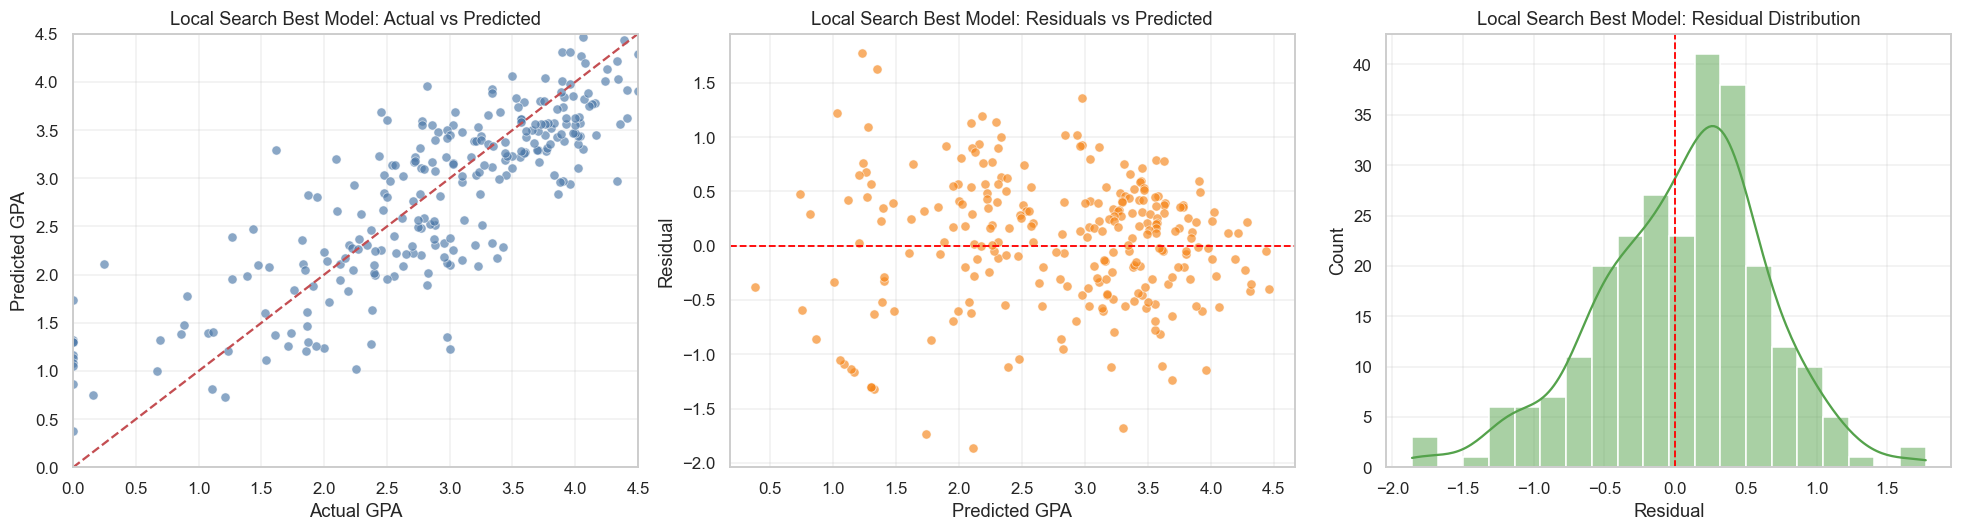

In [57]:
plot_prediction_diagnostics(local_test_df, title_prefix='Local Search Best Model')

### Model Comparison and Grouped Feature Importance

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Baseline,Validation,0.736493,0.542422,0.520806,0.541020,0.541020
1,Baseline,Test,0.622622,0.387658,0.477928,0.648617,0.648617
2,Baseline RNN,Validation,0.695574,0.483823,0.473483,0.590605,0.590605
3,Baseline RNN,Test,0.612803,0.375527,0.462066,0.659613,0.659613
4,Baseline LSTM,Validation,0.692768,0.479928,0.507628,0.593901,0.593901
5,Baseline LSTM,Test,0.597117,0.356549,0.472624,0.676816,0.676816
6,Hyperband Best,Validation,0.692515,0.479577,0.472309,0.594198,0.594198
7,Hyperband Best,Test,0.575908,0.331670,0.444145,0.699366,0.699366
8,Custom,Validation,0.695401,0.483583,0.499435,0.590808,0.590808
9,Custom,Test,0.593619,0.352384,0.462558,0.680591,0.680591


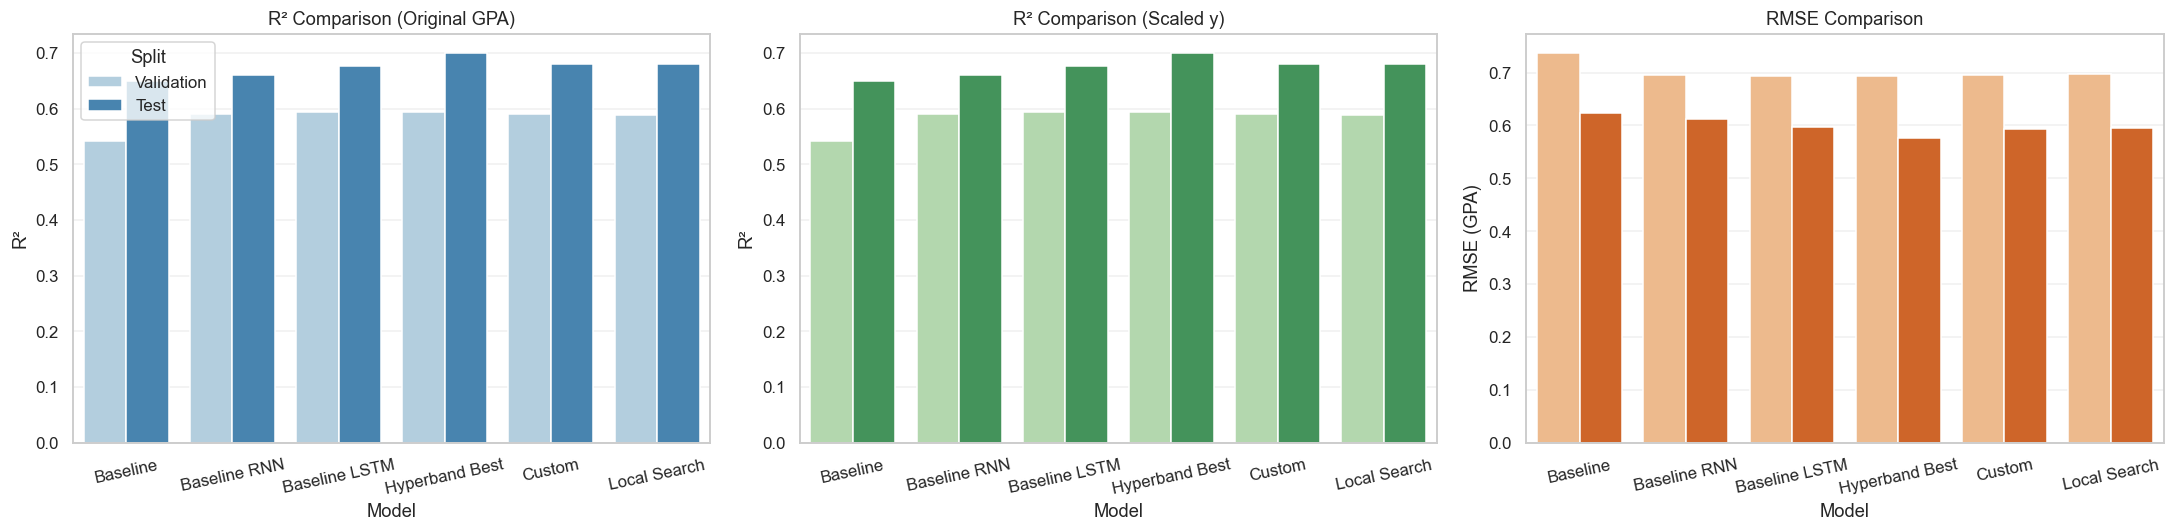

,Model,Split,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
0,Hyperband Best,Test,0.575908,0.331670,0.444145,0.699366,0.699366
1,Custom,Test,0.593619,0.352384,0.462558,0.680591,0.680591
2,Local Search,Test,0.594318,0.353214,0.471711,0.679839,0.679839
3,Baseline LSTM,Test,0.597117,0.356549,0.472624,0.676816,0.676816
4,Baseline RNN,Test,0.612803,0.375527,0.462066,0.659613,0.659613
5,Baseline,Test,0.622622,0.387658,0.477928,0.648617,0.648617


In [86]:
# Include every model family already explored in this notebook, not just the final dense/LSTM picks.
experiment_models = {
    'Baseline': baseline_model,
    'Baseline RNN': baseline_rnn,
    'Baseline LSTM': baseline_lstm,
    'Hyperband Best': best_model,
    'Custom': custom_model,
    'Local Search': best_local_model,
}

comparison_rows = [
    ('Baseline', 'Validation', baseline_val_metrics),
    ('Baseline', 'Test', baseline_test_metrics),
    ('Baseline RNN', 'Validation', baseline_rnn_val_metrics),
    ('Baseline RNN', 'Test', baseline_rnn_test_metrics),
    ('Baseline LSTM', 'Validation', baseline_lstm_val_metrics),
    ('Baseline LSTM', 'Test', baseline_lstm_test_metrics),
    ('Hyperband Best', 'Validation', best_val_metrics),
    ('Hyperband Best', 'Test', best_test_metrics),
    ('Custom', 'Validation', custom_val_metrics),
    ('Custom', 'Test', custom_test_metrics),
    ('Local Search', 'Validation', local_val_metrics),
    ('Local Search', 'Test', local_test_metrics),
]

comparison_df = pd.DataFrame([
    {
        'Model': model_name,
        'Split': split_name,
        **{k: v for k, v in metrics.items() if k != 'split'},
    }
    for model_name, split_name, metrics in comparison_rows
])

model_order = list(experiment_models.keys())
split_order = ['Validation', 'Test']
comparison_df['Model'] = pd.Categorical(comparison_df['Model'], categories=model_order, ordered=True)
comparison_df['Split'] = pd.Categorical(comparison_df['Split'], categories=split_order, ordered=True)
comparison_df = comparison_df.sort_values(['Model', 'Split']).reset_index(drop=True)

display(format_metrics_display(comparison_df))
plot_experiment_comparison(comparison_df)

test_rank_df = comparison_df[comparison_df['Split'] == 'Test'].sort_values(['r2_original', 'rmse'], ascending=[False, True]).reset_index(drop=True)
display(format_metrics_display(test_rank_df))

In [71]:
# export test predictions of the best model to csv for error analysis
best_test_df.to_csv(
    project_path / 'second_term_gpa_regression' / 'trial_results' / 'second_term_best_model_test_predictions.csv',
    index=False,
)

Selected model for grouped feature importance: Hyperband Best


,Feature Group,RMSE Increase (Mean),RMSE Increase (Std),R² Drop (Mean),Grouped Columns
0,first_term_gpa,0.091590,0.006810,0.103269,"first_term_gpa, first_term_gpa_sq"
1,gpa_math_interaction,0.085451,0.015084,0.096038,gpa_math_interaction
2,gpa_category,0.074571,0.006540,0.082934,"gpa_category_0, gpa_category_1, gpa_category_2..."
3,gpa_english_interaction,0.067189,0.002878,0.074247,gpa_english_interaction
4,gpa_hs_interaction,0.057444,0.003537,0.062976,gpa_hs_interaction
5,first_term_gpa_sq,0.047054,0.004272,0.051150,first_term_gpa_sq
6,hs_math_interaction,0.030169,0.004729,0.032343,hs_math_interaction
7,high_school_average_mark_missing,0.019032,0.001962,0.020202,high_school_average_mark_missing
8,preparedness_gap,0.017518,0.004562,0.018586,preparedness_gap
9,hs_math_gap,0.007731,0.003233,0.008135,hs_math_gap


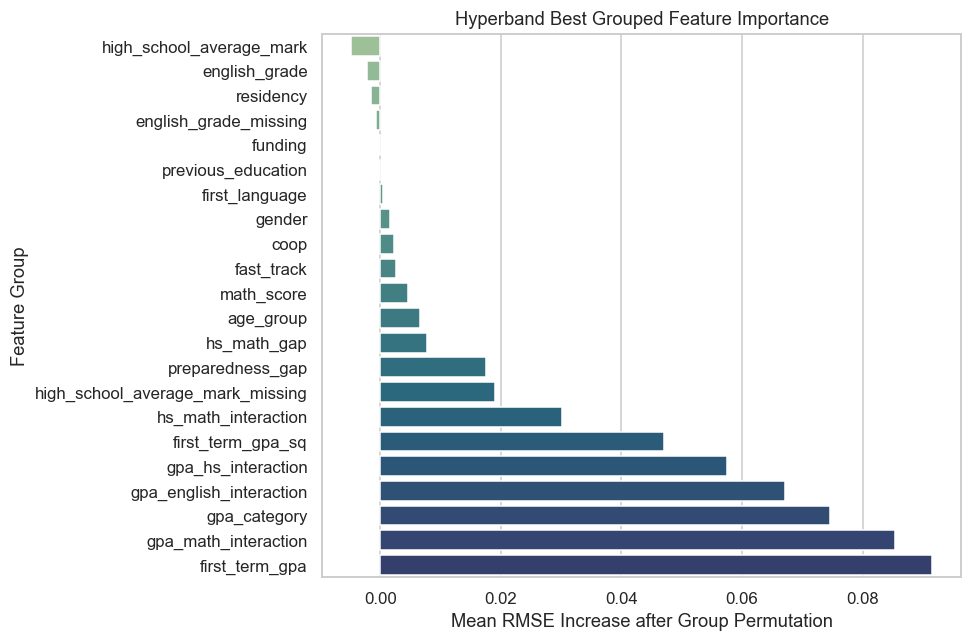

In [70]:
selected_model_name = test_rank_df.iloc[0]['Model']
selected_model = experiment_models[selected_model_name]
print(f'Selected model for grouped feature importance: {selected_model_name}')

grouped_importance_df = compute_grouped_permutation_importance(
    selected_model,
    X_test,
    y_test,
    scaler,
    n_repeats=3,
    random_state=42,
)

display(grouped_importance_df)
plot_grouped_feature_importance(
    grouped_importance_df,
    title=f'{selected_model_name} Grouped Feature Importance',
)

### Experiment 6: Relay Modeling to Predict Third Term GPA

In [153]:
# check the nan values in first_term_gpa and second_term_gpa columns
clean_df["first_term_gpa"] = clean_df["first_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")

print(f"Number of rows with nulls in first_term_gpa: {clean_df['first_term_gpa'].isna().sum()}")
print(f"Number of rows with nulls in second_term_gpa: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
clean_df = clean_df.dropna(subset=["first_term_gpa"])
print(f"Number of rows after dropping nulls in both first and second term GPA variables: {clean_df.shape[0]}")

Number of rows with nulls in first_term_gpa: 0
Number of rows with nulls in second_term_gpa: 0
Number of rows after dropping nulls in both first and second term GPA variables: 1277


In [154]:
clean_df.head()

,first_term_gpa,second_term_gpa,first_language,funding,school,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,third_term_gpa_proxy
0,0.000000,0.000000,1,2.0,6.0,2.0,1.0,1.0,2.0,1,1,59,16,7,1.0,0.000000
1,2.500000,2.000000,3,4.0,6.0,1.0,2.0,2.0,2.0,1,3,?,?,7,1.0,2.200000
2,4.250000,3.923077,1,1.0,6.0,2.0,1.0,1.0,1.0,2,3,92,41,9,1.0,4.053846
3,3.020833,2.321429,3,4.0,6.0,1.0,2.0,2.0,2.0,2,3,?,?,8,1.0,2.601191
4,4.275000,4.326923,1,2.0,6.0,1.0,1.0,1.0,1.0,2,3,97,?,9,1.0,4.306154


In [155]:
# Synthetic proxy for third-term GPA (relay model):
# Weighted progression from first- and second-term GPA,
# conditioned on first-year persistence (non-persistent students assigned 0)
clean_df["third_term_gpa_proxy"] = (
    0.6 * clean_df["second_term_gpa"] + 0.4 * clean_df["first_term_gpa"]
) * clean_df["first_year_persistence"]

# Feature and target separation
y_new = clean_df["third_term_gpa_proxy"] # third_term_gpa_proxy 
X_new = clean_df.drop(columns=["school", "third_term_gpa_proxy"]) # Drop school - unique value

In [156]:
# Replace second_term_gpa with predictions from the best model
# to create a fully synthetic dataset for third-term GPA prediction

# Preprocess new input data
X_new_features = cleaner.transform(
    X_new.drop(columns=["second_term_gpa", "first_year_persistence"])
)

# Scale actual second_term_gpa for comparison
y_new_scaled = scaler.transform(
    X_new["second_term_gpa"].values.reshape(-1, 1)
).flatten()

X_new_lstm = np.asarray(X_new_features).astype(np.float32).reshape(X_new_features.shape[0], X_new_features.shape[1], 1)

# Evaluate best model on test set
best_test_metrics, predicted_df = evaluate_model_original_scale(
    best_model,
    X_new_lstm,
    y_new_scaled,
    scaler,
    split_name="Hyperband Test"
)

display(predicted_df.head(15))

#save results to csv
predicted_df.to_csv(
project_path / 'second_term_gpa_regression' / 'trial_results' / 'third_term_gpa_proxy_predictions.csv',
    index=False,
)

Hyperband Test RMSE: 0.6712
Hyperband Test MSE:  0.4505
Hyperband Test MAE:              0.5198
Hyperband Test R² (Original GPA): 0.6461
Hyperband Test R² (Scaled y):     0.6461


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.700000,0.632534,3.067466,3.067466,9.409347
1,0.136364,3.195026,-3.058662,3.058662,9.355416
2,0.000000,3.022357,-3.022357,3.022357,9.134640
3,3.676471,1.323323,2.353148,2.353148,5.537304
4,0.000000,2.330701,-2.330701,2.330701,5.432169
5,0.000000,2.313897,-2.313897,2.313897,5.354119
6,0.000000,2.286426,-2.286426,2.286426,5.227745
7,0.000000,2.261242,-2.261242,2.261242,5.113216
8,1.090909,3.305413,-2.214504,2.214504,4.904029
9,0.000000,2.214344,-2.214344,2.214344,4.903319


In [157]:
X_new["predicted_second_term_gpa"] = predicted_df["Predicted GPA"].values
X_new.head()

,first_term_gpa,second_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,predicted_second_term_gpa
0,0.000000,0.000000,1,2.0,2.0,1.0,1.0,2.0,1,1,59,16,7,1.0,0.632534
1,2.500000,2.000000,3,4.0,1.0,2.0,2.0,2.0,1,3,?,?,7,1.0,3.195026
2,4.250000,3.923077,1,1.0,2.0,1.0,1.0,1.0,2,3,92,41,9,1.0,3.022357
3,3.020833,2.321429,3,4.0,1.0,2.0,2.0,2.0,2,3,?,?,8,1.0,1.323323
4,4.275000,4.326923,1,2.0,1.0,1.0,1.0,1.0,2,3,97,?,9,1.0,2.330701


In [158]:
# Drop original column
X_new = X_new.drop(columns=["second_term_gpa"])

# Rename predicted → official column
if "predicted_second_term_gpa" in X_new.columns:
    X_new = X_new.rename(
        columns={"predicted_second_term_gpa": "second_term_gpa"}
    )

X_new.head()

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,second_term_gpa
0,0.000000,1,2.0,2.0,1.0,1.0,2.0,1,1,59,16,7,1.0,0.632534
1,2.500000,3,4.0,1.0,2.0,2.0,2.0,1,3,?,?,7,1.0,3.195026
2,4.250000,1,1.0,2.0,1.0,1.0,1.0,2,3,92,41,9,1.0,3.022357
3,3.020833,3,4.0,1.0,2.0,2.0,2.0,2,3,?,?,8,1.0,1.323323
4,4.275000,1,2.0,1.0,1.0,1.0,1.0,2,3,97,?,9,1.0,2.330701


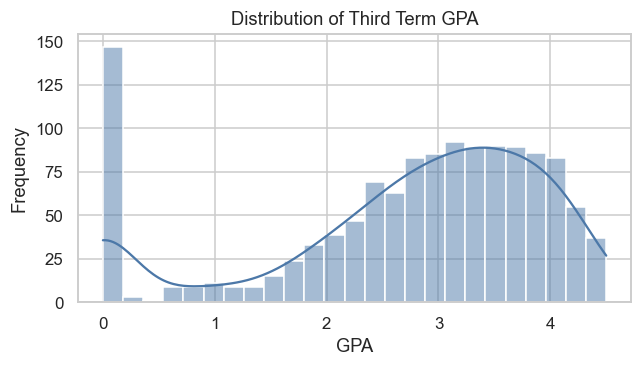

In [159]:
# check target variable distribution

plt.figure(figsize=(6,3.5))

sns.histplot(y_new, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Third Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [160]:
# test-train split with stratification and train-only feature fitting
X_new_train_raw, X_new_test, y_new_train, y_new_test = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42,
)

X_new_train, X_new_val, y_new_train, y_new_val = train_test_split(
    X_new_train_raw,
    y_new_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_new_train: {X_new_train.shape}, X_new_val: {X_new_val.shape}, X_new_test: {X_new_test.shape}")

X_new_train: (893, 14), X_new_val: (128, 14), X_new_test: (256, 14)


In [161]:
# check the final training dataset
display(X_new_train.head())

,first_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,second_term_gpa
78,3.521739,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7,1.0,1.944091
353,2.250000,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7,1.0,3.121213
1354,3.400000,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8,1.0,3.084149
510,4.214286,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9,1.0,0.562509
338,2.547619,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9,0.0,3.496162


### Data Cleaning

In [162]:
# Data cleaning

from second_term_gpa_regression.utils.data_cleaner_proxy import DataCleaner

cleaner_2 = DataCleaner(numeric_imputer="bayesian")

X_new_train = cleaner_2.fit_transform(X_new_train)
X_new_val = cleaner_2.transform(X_new_val)
X_new_test = cleaner_2.transform(X_new_test)

# Target standardization
scaler = MinMaxScaler()
y_new_train = scaler.fit_transform(y_new_train.values.reshape(-1, 1)).flatten()
y_new_val = scaler.transform(y_new_val.values.reshape(-1, 1)).flatten()
y_new_test = scaler.transform(y_new_test.values.reshape(-1, 1)).flatten()

In [164]:
import joblib

# save the preprocessing pipeline (DataCleaner object) to a file for later use in inference
joblib.dump(cleaner_2, project_path / "second_term_gpa_regression" / "models" / 'best_second_term_regression_model' / "relay_third_term_preprocessing_pipeline.pkl")
joblib.dump(scaler, project_path / "second_term_gpa_regression" / "models" / 'best_second_term_regression_model' / "relay_third_term_target_scaler.pkl")

# check the training after cleaning
display(X_train.head())

,first_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,high_school_average_mark_missing,english_grade_missing,...,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3,gpa_category_0,gpa_category_1,gpa_category_2,gpa_category_3
78,0.485630,1,0,0,3.0,0.335862,0.248844,7.0,1,0,...,True,False,False,True,False,False,False,False,False,True
353,-0.762264,0,0,1,2.0,0.270222,0.122663,7.0,0,0,...,False,True,False,False,True,False,False,False,True,False
1354,0.366174,1,0,0,4.0,0.253814,0.187655,8.0,1,0,...,True,False,False,False,True,False,False,False,False,True
510,1.165193,0,1,1,4.0,-0.751768,1.665857,9.0,0,0,...,False,True,False,False,True,False,False,False,False,True
338,-0.470226,0,1,1,2.0,-0.240773,-0.703704,9.0,0,0,...,False,True,False,True,False,False,False,False,True,False


In [165]:
baseline_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2},
]

baseline_model = build_dense_model(X_train.shape[1], baseline_layers)
baseline_model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 516)                 │          19,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_29               │ (None, 516)                 │           2,064 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 516)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 128)                 │          66,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_30               │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 88,489 (345.66 KB)

 Trainable params: 87,201 (340.63 KB)

 Non-trainable params: 1,288 (5.03 KB)

In [166]:
baseline_model = compile_regression_model(baseline_model, optimizer_name='sgd', learning_rate=0.0009)

baseline_es, baseline_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'best_second_term_regression_model' / 'relay_third_term_regression_ann_model.keras')

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[baseline_es, baseline_mc],
    verbose=1,
)

Epoch 1/200
24/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4406 - mae: 0.9503 - r2: -22.6976 - rmse: 1.1982
Epoch 1: val_loss improved from None to 0.07726, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_second_term_regression_model\relay_third_term_regression_ann_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\best_second_term_regression_model\relay_third_term_regression_ann_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 1.1532 - mae: 0.8427 - r2: -16.5069 - rmse: 1.0739 - val_loss: 0.0773 - val_mae: 0.2355 - val_r2: -0.3238 - val_rmse: 0.2780
Epoch 2/200
22/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6234 - mae: 0.6059 - r2: -8.9446 - rmse: 0.7888
Epoch 2: val_loss improved from 0.07726 to 0.06552, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neura

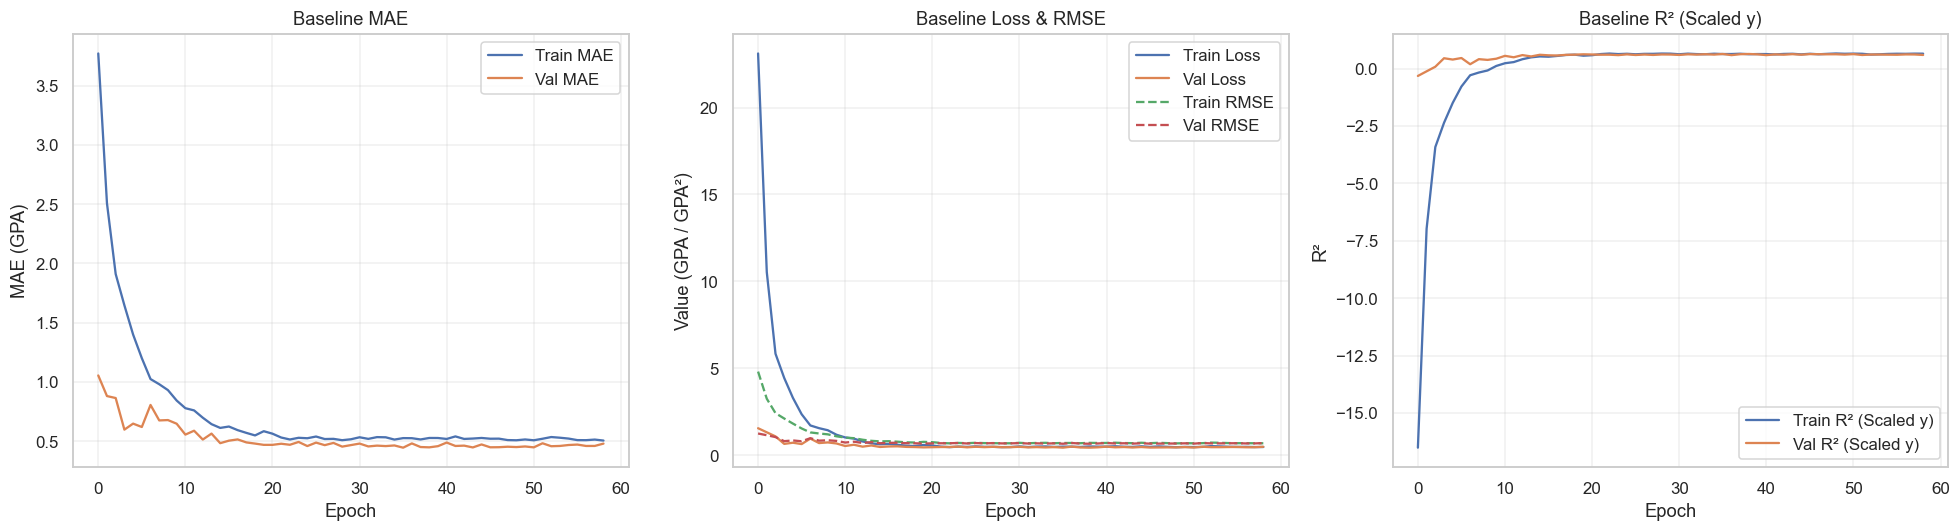


Best Epoch: 39
----------------------------------------
MAE (GPA)   -> Train: 0.5269 | Val: 0.4478
RMSE (GPA)  -> Train: 0.7066 | Val: 0.6555
Loss (GPA²) -> Train: 0.4993 | Val: 0.4296
R² (Scaled y) -> Train: 0.6218 | Val: 0.6327


In [170]:
plot_regression_history(history_baseline, title_prefix='Baseline')

In [171]:
baseline_val_metrics, baseline_val_df = evaluate_model_original_scale(
    baseline_model, X_val, y_val, scaler, split_name='Baseline Validation'
)
baseline_test_metrics, baseline_test_df = evaluate_model_original_scale(
    baseline_model, X_test, y_test, scaler, split_name='Baseline Test'
)

baseline_summary_df = pd.DataFrame([baseline_val_metrics, baseline_test_metrics]).set_index('split')
display(format_metrics_display(baseline_summary_df))
display(baseline_test_df.head(15))


Baseline Validation RMSE: 0.6555
Baseline Validation MSE:  0.4296
Baseline Validation MAE:              0.4478
Baseline Validation R² (Original GPA): 0.6327
Baseline Validation R² (Scaled y):     0.6327
Baseline Test RMSE: 0.5731
Baseline Test MSE:  0.3285
Baseline Test MAE:              0.4326
Baseline Test R² (Original GPA): 0.6992
Baseline Test R² (Scaled y):     0.6992


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline Validation,0.655473,0.429645,0.447786,0.632691,0.632691
Baseline Test,0.573142,0.328492,0.432626,0.699170,0.699170


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,2.984615,0.996240,1.988375,1.988375,3.953635
1,0.000000,1.865947,-1.865947,1.865947,3.481758
2,2.962988,1.215864,1.747124,1.747124,3.052443
3,0.000000,1.706553,-1.706553,1.706553,2.912325
4,0.248718,1.948320,-1.699602,1.699602,2.888646
5,0.000000,1.668900,-1.668900,1.668900,2.785227
6,0.000000,1.575534,-1.575534,1.575534,2.482306
7,3.079365,1.681101,1.398264,1.398264,1.955143
8,3.205698,1.809706,1.395992,1.395992,1.948793
9,1.610745,2.942479,-1.331734,1.331734,1.773515


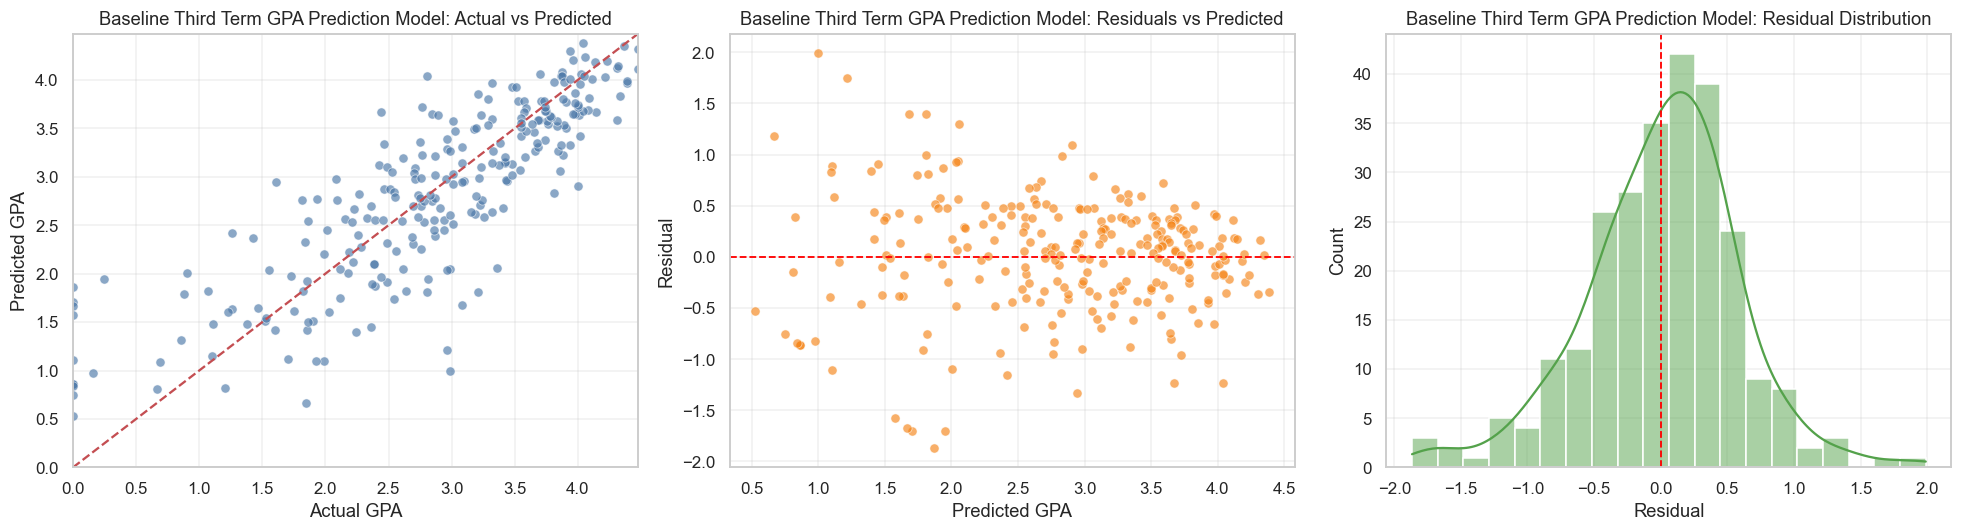

In [172]:
plot_prediction_diagnostics(baseline_test_df, title_prefix='Baseline Third Term GPA Prediction Model')

,Feature Group,RMSE Increase (Mean),RMSE Increase (Std),R² Drop (Mean),Grouped Columns
0,first_term_gpa,0.110076,0.008629,0.126718,"first_term_gpa, first_term_gpa_sq"
1,preparedness_gap,0.058833,0.004250,0.064947,preparedness_gap
2,high_school_average_mark,0.028933,0.002004,0.031143,high_school_average_mark
3,gpa_hs_interaction,0.019047,0.002843,0.020334,gpa_hs_interaction
4,age_group,0.016316,0.003842,0.017385,age_group
5,gpa_math_interaction,0.015305,0.008448,0.016346,gpa_math_interaction
6,hs_math_gap,0.013529,0.001743,0.014373,hs_math_gap
7,hs_math_interaction,0.012021,0.003390,0.012762,hs_math_interaction
8,gpa_english_interaction,0.009379,0.003561,0.009938,gpa_english_interaction
9,first_term_gpa_sq,0.004744,0.007084,0.005047,first_term_gpa_sq


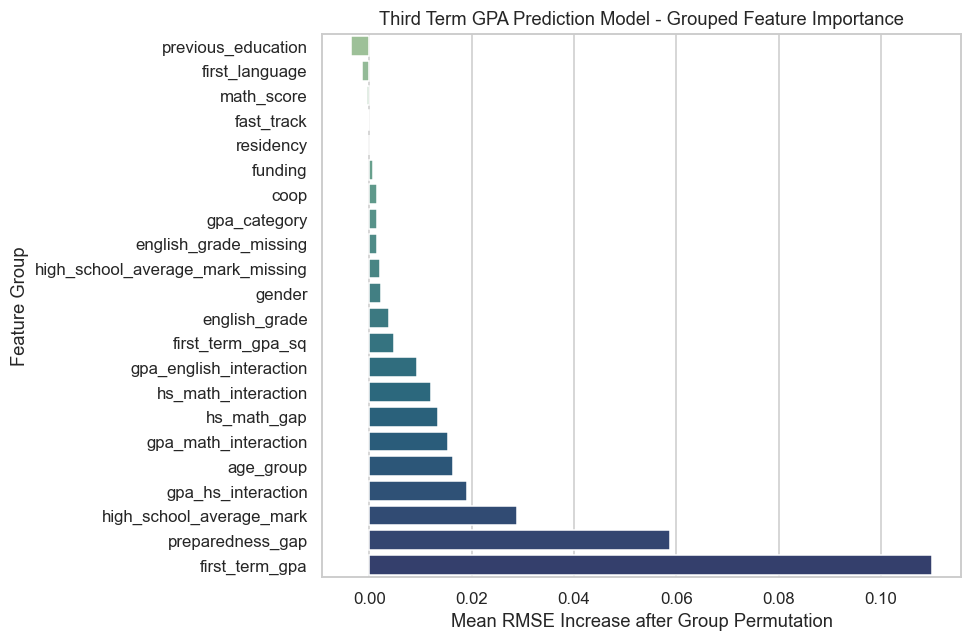

In [173]:
grouped_importance_df = compute_grouped_permutation_importance(
    baseline_model,
    X_test,
    y_test,
    scaler,
    n_repeats=3,
    random_state=42,
)

display(grouped_importance_df)
plot_grouped_feature_importance(
    grouped_importance_df,
    title=f'Third Term GPA Prediction Model - Grouped Feature Importance',
)